## Data analysis poject on Brazilian E-Commerce Public Dataset by Olist from Kaggle

#### Importing required libraries

In [246]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

#### Load data

In [247]:
# customer = pd.read_csv('/kaggle/input/brazilian-ecommerce/olist_customer_dataset.csv') [For Kaggle]

customer = pd.read_csv('D:/Data Analysis Project/ecommerce/olist_customers_dataset.csv')
geolocation = pd.read_csv('D:/Data Analysis Project/ecommerce/olist_geolocation_dataset.csv')
order_item = pd.read_csv('D:/Data Analysis Project/ecommerce/olist_order_items_dataset.csv')
order_payments = pd.read_csv('D:/Data Analysis Project/ecommerce/olist_order_payments_dataset.csv')
order_review = pd.read_csv('D:/Data Analysis Project/ecommerce/olist_order_reviews_dataset.csv')
order = pd.read_csv('D:/Data Analysis Project/ecommerce/olist_orders_dataset.csv')
products = pd.read_csv('D:/Data Analysis Project/ecommerce/olist_products_dataset.csv')
sellers = pd.read_csv('D:/Data Analysis Project/ecommerce/olist_sellers_dataset.csv')
prod_cat = pd.read_csv('D:/Data Analysis Project/ecommerce/product_category_name_translation.csv')

## Data Analysis Part

### Viewing summary of the DataFrame’s structure.

In [248]:
print('Customer dataset info')
customer.info()
print('-'*70)

print('Location dataset info')
geolocation.info()
print('-'*70)

print('Order_item dataset info')
order_item.info()
print('-'*70)

print('Order_payments info')
order_payments.info()
print('-'*70)

print('Order_review info')
order_review.info()
print('-'*70)

print('Order info')
order.info()
print('-'*70)

print('Products info')
products.info()
print('-'*70)

print('Sellers info')
sellers.info()
print('-'*70)

print('Product_category info')
prod_cat.info()

Customer dataset info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
----------------------------------------------------------------------
Location dataset info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float

### Data type conversation

In [249]:
order_item['shipping_limit_date'] = pd.to_datetime(order_item['shipping_limit_date'],format='mixed')
print(order_item.dtypes)

order_review['review_creation_date'] = pd.to_datetime(order_review['review_creation_date'],format='mixed')
order_review['review_answer_timestamp'] = order_review['review_answer_timestamp'].str[:19]
order_review['review_answer_timestamp'] = pd.to_datetime(
    order_review['review_answer_timestamp'], errors='coerce'
)
order['order_purchase_timestamp'] = pd.to_datetime(order['order_purchase_timestamp'],format='mixed')
order['order_approved_at'] = pd.to_datetime(order['order_approved_at'],format='mixed')
order['order_delivered_carrier_date'] = pd.to_datetime(order['order_delivered_carrier_date'],format='mixed')
order['order_delivered_customer_date'] = pd.to_datetime(order['order_delivered_customer_date'],format='mixed')
order['order_estimated_delivery_date'] = pd.to_datetime(order['order_estimated_delivery_date'],format='mixed')

order_id                       object
order_item_id                   int64
product_id                     object
seller_id                      object
shipping_limit_date    datetime64[ns]
price                         float64
freight_value                 float64
dtype: object


### Rename Mispelled Column Name

In [250]:
products.rename(columns = {'product_name_lenght':'product_name_length',
'product_description_lenght':'product_description_length'})

,product_id,product_category_name,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


### Missing Value Handling

In [251]:
print(f'Missing Value in Orders Data: {order.isna().sum()}')

print('*'*50)

print(f'Missing Value in Orders_reiew Data: {order_review.isna().sum()}')

print('*'*50)

print(f'Missing Value in Products Data: {products.isna().sum()}')


Missing Value in Orders Data: order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
**************************************************
Missing Value in Orders_reiew Data: review_id                      0
order_id                       0
review_score                   0
review_comment_title       87655
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        1
dtype: int64
**************************************************
Missing Value in Products Data: product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
p

In [252]:
# inplace delivered carrier date in order deliver customer date if null

order['order_delivered_customer_date'] = (order['order_delivered_customer_date'].fillna(order['order_delivered_carrier_date']))

print(f'Missing Value in Orders Data: {order.isna().sum()}')

Missing Value in Orders Data: order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    1782
order_estimated_delivery_date       0
dtype: int64


In [253]:
# check % of naull value in dataset basd on own row number

order.isnull().sum()/order.shape[0] *100

order_id                         0.000000
customer_id                      0.000000
order_status                     0.000000
order_purchase_timestamp         0.000000
order_approved_at                0.160899
order_delivered_carrier_date     1.793023
order_delivered_customer_date    1.792017
order_estimated_delivery_date    0.000000
dtype: float64

In [254]:
order.dropna(axis=0, how='any', inplace=True, ignore_index=True)

display(order.isna().sum().sum())
display(order.shape)

0

(97644, 8)

In [255]:
order_review.shape

(99223, 7)

In [256]:
order_review.isna().sum()/order_review.shape[0] * 100

review_id                   0.000000
order_id                    0.000000
review_score                0.000000
review_comment_title       88.341413
review_comment_message     58.703123
review_creation_date        0.000000
review_answer_timestamp     0.001008
dtype: float64

In [257]:
order_review.fillna('unknown', inplace=True)
order_review.isna().sum()/order_review.shape[0] * 100

C:\Users\user\AppData\Local\Temp\ipykernel_14560\2233800881.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'unknown' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  order_review.fillna('unknown', inplace=True)


review_id                  0.0
order_id                   0.0
review_score               0.0
review_comment_title       0.0
review_comment_message     0.0
review_creation_date       0.0
review_answer_timestamp    0.0
dtype: float64

In [258]:
products.isna().sum()/products.shape[0] * 100

product_id                    0.000000
product_category_name         1.851234
product_name_lenght           1.851234
product_description_lenght    1.851234
product_photos_qty            1.851234
product_weight_g              0.006070
product_length_cm             0.006070
product_height_cm             0.006070
product_width_cm              0.006070
dtype: float64

In [259]:
products.dropna(axis=0, how='any', inplace=True, ignore_index=True)

In [260]:
products.isna().sum()/products.shape[0] * 100

product_id                    0.0
product_category_name         0.0
product_name_lenght           0.0
product_description_lenght    0.0
product_photos_qty            0.0
product_weight_g              0.0
product_length_cm             0.0
product_height_cm             0.0
product_width_cm              0.0
dtype: float64

### Duplicate Hnadling

*	When you join tables (say, merging  with ), you often create duplicates because one order can have multiple items.
*	If you try to remove duplicates before joining, you might miss the true picture — because duplicates can multiply or change after the join.
*	So the advice is: wait until after the join to handle duplicates, because then you’ll see the “extremeness” (the full extent) of duplication across combined data.

In [261]:
# checking duplicates in customer table
print(customer.duplicated().sum())
print(customer['customer_id'].duplicated().sum())
print(customer['customer_unique_id'].duplicated().sum())

0
0
3345


In [262]:
customer[customer['customer_unique_id'].duplicated(keep=False)].sort_values(by='customer_unique_id')

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
35608,24b0e2bd287e47d54d193e7bbb51103f,00172711b30d52eea8b313a7f2cced02,45200,jequie,BA
19299,1afe8a9c67eec3516c09a8bdcc539090,00172711b30d52eea8b313a7f2cced02,45200,jequie,BA
20023,1b4a75b3478138e99902678254b260f4,004288347e5e88a27ded2bb23747066c,26220,nova iguacu,RJ
22066,f6efe5d5c7b85e12355f9d5c3db46da2,004288347e5e88a27ded2bb23747066c,26220,nova iguacu,RJ
72451,49cf243e0d353cd418ca77868e24a670,004b45ec5c64187465168251cd1c9c2f,57055,maceio,AL
...,...,...,...,...,...
75057,1ae563fdfa500d150be6578066d83998,ff922bdd6bafcdf99cb90d7f39cea5b3,17340,barra bonita,SP
27992,bec0bf00ac5bee64ce8ef5283051a70c,ff922bdd6bafcdf99cb90d7f39cea5b3,17340,barra bonita,SP
79859,d064be88116eb8b958727aec4cf56a59,ff922bdd6bafcdf99cb90d7f39cea5b3,17340,barra bonita,SP
64323,4b231c90751c27521f7ee27ed2dc3b8f,ffe254cc039740e17dd15a5305035928,37640,extrema,MG


#### We will keep duplicate cusomer unique_ID as -

* A single customer (customer_unique_id) can place multiple orders.
* Each order gets its own customer_id (unique per row).
* So you’ll see the same  repeated across different rows, but with different customer_id

In [263]:
# checking duplicates in order table
print(order.duplicated().sum())
print(order['order_id'].duplicated().sum())
print(order['customer_id'].duplicated().sum())

0
0
0


In [264]:
# checking duplicates in order_item table

print(order_item.duplicated().sum())

# Check duplicates on candidate key combination
print(order_item.duplicated(subset=['order_id', 'order_item_id'] ).sum())

print(order_item['order_id'].duplicated().sum())
print(order_item['product_id'].duplicated().sum())
print(order_item['seller_id'].duplicated().sum())

0
0
13984
79699
109555


In [265]:
# checking duplicates in order_payments table
print(order_payments.duplicated().sum())

# Check duplicates on candidate key combination
print(order_payments.duplicated(subset=['order_id', 'payment_sequential'] ).sum())

print(order_payments['order_id'].duplicated().sum()) # It may have duplicates due to installment pay

0
0
4446


In [266]:
# checking duplicates in order_review table
print(order_review.duplicated().sum())
print(order_review['review_id'].duplicated().sum())

0
814


In [267]:
order_review[order_review['review_id'].duplicated(keep=False)].sort_values(by='review_id')

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
46678,00130cbe1f9d422698c812ed8ded1919,dfcdfc43867d1c1381bfaf62d6b9c195,1,unknown,"O cartucho ""original HP"" 60XL não é reconhecid...",2018-03-07,2018-03-20 18:08:00
29841,00130cbe1f9d422698c812ed8ded1919,04a28263e085d399c97ae49e0b477efa,1,unknown,"O cartucho ""original HP"" 60XL não é reconhecid...",2018-03-07,2018-03-20 18:08:00
90676,0115633a9c298b6a98bcbe4eee75345f,78a4201f58af3463bdab842eea4bc801,5,unknown,unknown,2017-09-21,2017-09-26 03:27:00
63193,0115633a9c298b6a98bcbe4eee75345f,0c9850b2c179c1ef60d2855e2751d1fa,5,unknown,unknown,2017-09-21,2017-09-26 03:27:00
92875,0174caf0ee5964646040cd94e15ac95e,f93a732712407c02dce5dd5088d0f47b,1,unknown,Produto entregue dentro de embalagem do fornec...,2018-03-07,2018-03-08 03:00:00
...,...,...,...,...,...,...,...
31120,fe5c833752953fed3209646f1f63b53c,4863e15fa53273cc7219c58f5ffda4fb,1,unknown,"Comprei dois produtos e ambos, mesmo enviados ...",2018-02-28,2018-02-28 13:57:00
7870,ff2fc9e68f8aabfbe18d710b83aabd30,2da58e0a7dcfa4ce1e00fad9d03ca3b5,2,unknown,unknown,2018-03-17,2018-03-19 11:44:00
82520,ff2fc9e68f8aabfbe18d710b83aabd30,1078d496cc6ab9a8e6f2be77abf5091b,2,unknown,unknown,2018-03-17,2018-03-19 11:44:00
73950,ffb8cff872a625632ac983eb1f88843c,c44883fc2529b4aa03ca90e7e09d95b6,3,unknown,unknown,2017-07-22,2017-07-26 13:41:00


In [268]:
# to remove duplicate

# review_ratings.drop_duplicates(subset='review_id', keep='first')

In [269]:
order_review['unique_key'] = order_review[['review_id', 'order_id']].astype(str).agg('_'. join, axis=1 )
order_review.columns

Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'unique_key'],
      dtype='object')

In [270]:
print(order_review['unique_key'].duplicated().sum())

0


#### As in unique_key there is no duplication it means all reviews are unique. So, we keep all review

In [271]:
# checking duplicates in products table
print(products.duplicated().sum())
print(products['product_id'].duplicated().sum())

0
0


In [272]:
# checking duplicates in sellers table
print(sellers.duplicated().sum())
print(sellers['seller_id'].duplicated().sum())
print(sellers['seller_zip_code_prefix'].duplicated().sum())

0
0
849


In [273]:
# checking duplicates in geolocation table

print(geolocation.duplicated().sum())
print(geolocation['geolocation_zip_code_prefix'].duplicated().sum()) # This checks only the single column 
print(geolocation.duplicated(subset=['geolocation_zip_code_prefix']).sum()) # This checks entire rows, but only considers the column when deciding duplicates

261831
981148
981148


In [274]:
# checking duplicates in prod_category table

print(prod_cat.duplicated().sum())
print(prod_cat['product_category_name'].duplicated().sum())
print(prod_cat['product_category_name_english'].duplicated().sum())

0
0
0


### Generate statistical information of each table

In [275]:
print('Customer dataset statistical info')
print(customer.describe())

print('-'*70)

print('Location dataset statistical info')
print(geolocation.describe())

print('-'*70)

print('Order_item dataset statistical info')
print(order_item.describe())

print('-'*70)

print('Order_payments statistical info')
print(order_payments.describe())

print('-'*70)

print('Order_review statistical info')
print(order_review.describe())

print('-'*70)

print('Order statistical info')
print(order.describe())

print('-'*70)

print('Products statistical info')
print(products.describe())

print('-'*70)

Customer dataset statistical info
       customer_zip_code_prefix
count              99441.000000
mean               35137.474583
std                29797.938996
min                 1003.000000
25%                11347.000000
50%                24416.000000
75%                58900.000000
max                99990.000000
----------------------------------------------------------------------
Location dataset statistical info
       geolocation_zip_code_prefix  geolocation_lat  geolocation_lng
count                 1.000163e+06     1.000163e+06     1.000163e+06
mean                  3.657417e+04    -2.117615e+01    -4.639054e+01
std                   3.054934e+04     5.715866e+00     4.269748e+00
min                   1.001000e+03    -3.660537e+01    -1.014668e+02
25%                   1.107500e+04    -2.360355e+01    -4.857317e+01
50%                   2.653000e+04    -2.291938e+01    -4.663788e+01
75%                   6.350400e+04    -1.997962e+01    -4.376771e+01
max                  

### Handle some data inconsistency 

In [276]:
order_item.sort_values(by = 'shipping_limit_date',ascending=True)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
101394,e5fa5a7210941f7d56d0208e4e071d35,1,f3c2d01a84c947b078e32bbef0718962,a425f92c199eb576938df686728acd20,2016-09-19 00:15:34,59.50,15.56
84389,bfbd0f9bdef84302105ad712db648a6c,1,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,2016-09-19 23:11:33,44.99,2.83
84390,bfbd0f9bdef84302105ad712db648a6c,2,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,2016-09-19 23:11:33,44.99,2.83
84391,bfbd0f9bdef84302105ad712db648a6c,3,5a6b04657a4c5ee34285d1e4619a96b4,ecccfa2bb93b34a3bf033cc5d1dcdc69,2016-09-19 23:11:33,44.99,2.83
90368,cd3b8574c82b42fc8129f6d502690c3e,1,e2a1d45a73dc7f5a7f9236b043431b89,b499c00f28f4b7069ff6550af8c1348a,2016-10-08 10:34:01,29.99,10.96
...,...,...,...,...,...,...,...
26104,3b61aab5de69abc1731138bd104a777f,1,6aa063e063f2ab982b471e58afe06d72,610f72e407cdd7caaa2f8167b0163fd8,2018-09-18 21:10:15,999.99,24.77
68516,9c94a4ea2f7876660fa6f1b59b69c8e6,1,282b126b2354516c5f400154398f616d,7a241947449cc45dbfda4f9d0798d9d0,2020-02-03 20:23:22,75.99,14.70
8643,13bdf405f961a6deec817d817f5c6624,1,96ea060e41bdecc64e2de00b97068975,7a241947449cc45dbfda4f9d0798d9d0,2020-02-05 03:30:51,69.99,14.66
85730,c2bb89b5c1dd978d507284be78a04cb2,2,87b92e06b320e803d334ac23966c80b1,7a241947449cc45dbfda4f9d0798d9d0,2020-04-09 22:35:08,99.99,61.44


In [277]:
order_item[order_item['shipping_limit_date'].dt.year<2016]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value


In [278]:
order_item[order_item['shipping_limit_date'].dt.year>2018]

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
8643,13bdf405f961a6deec817d817f5c6624,1,96ea060e41bdecc64e2de00b97068975,7a241947449cc45dbfda4f9d0798d9d0,2020-02-05 03:30:51,69.99,14.66
68516,9c94a4ea2f7876660fa6f1b59b69c8e6,1,282b126b2354516c5f400154398f616d,7a241947449cc45dbfda4f9d0798d9d0,2020-02-03 20:23:22,75.99,14.70
85729,c2bb89b5c1dd978d507284be78a04cb2,1,87b92e06b320e803d334ac23966c80b1,7a241947449cc45dbfda4f9d0798d9d0,2020-04-09 22:35:08,99.99,61.44
85730,c2bb89b5c1dd978d507284be78a04cb2,2,87b92e06b320e803d334ac23966c80b1,7a241947449cc45dbfda4f9d0798d9d0,2020-04-09 22:35:08,99.99,61.44


#### As there are only 4 rows after 2018, we can remove those rows and can calculate business scope form 2016 to 2018

In [279]:
order_item = order_item[order_item['shipping_limit_date'].dt.year <= 2018]
print(order_item[order_item['shipping_limit_date'].dt.year>2018])

Empty DataFrame
Columns: [order_id, order_item_id, product_id, seller_id, shipping_limit_date, price, freight_value]
Index: []


In [280]:
products.head(3)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0


#### In products table there are some products which weight is 0, which can not be possible. So we will remove the products which weight is near 0

In [281]:
print(products[products['product_weight_g']==0].describe())
print('~~'*50)
print(products[products['product_weight_g']==0].shape)

       product_name_lenght  product_description_lenght  product_photos_qty  \
count             4.000000                        4.00                 4.0   
mean             51.250000                      528.25                 1.0   
std               2.362908                        0.50                 0.0   
min              48.000000                      528.00                 1.0   
25%              50.250000                      528.00                 1.0   
50%              52.000000                      528.00                 1.0   
75%              53.000000                      528.25                 1.0   
max              53.000000                      529.00                 1.0   

       product_weight_g  product_length_cm  product_height_cm  \
count               4.0                4.0                4.0   
mean                0.0               30.0               25.0   
std                 0.0                0.0                0.0   
min                 0.0              

In [282]:
products = products[products['product_weight_g']!=0]

In [283]:
# Viewing table column name
def show_columns(dfs: dict):

    for name, df in dfs.items():
        print(f"{name} columns:")
        print(df.columns.tolist())
        print('-' * 70)

# Example usage:
datasets = {
    "Customer": customer,
    "Location": geolocation,
    "Order_item": order_item,
    "Order_payments": order_payments,
    "Order_review": order_review,
    "Order": order,
    "Products": products,
    "Sellers": sellers,
    "Product_category": prod_cat
}

show_columns(datasets)

Customer columns:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']
----------------------------------------------------------------------
Location columns:
['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']
----------------------------------------------------------------------
Order_item columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
----------------------------------------------------------------------
Order_payments columns:
['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']
----------------------------------------------------------------------
Order_review columns:
['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp', 'unique_key']
-----------------------------------------------

In [284]:
# Viewing shape of table after cleaning
def shape(dfs:dict):
    for name, df in dfs.items():
        print(f'{name} Shape')
        print(df.shape)
        print('-' * 70)

datasets = {
    "Customer": customer,
    "Location": geolocation,
    "Order_item": order_item,
    "Order_payments": order_payments,
    "Order_review": order_review,
    "Order": order,
    "Products": products,
    "Sellers": sellers,
    "Product_category": prod_cat
}

shape(datasets)

Customer Shape
(99441, 5)
----------------------------------------------------------------------
Location Shape
(1000163, 5)
----------------------------------------------------------------------
Order_item Shape
(112646, 7)
----------------------------------------------------------------------
Order_payments Shape
(103886, 5)
----------------------------------------------------------------------
Order_review Shape
(99223, 8)
----------------------------------------------------------------------
Order Shape
(97644, 8)
----------------------------------------------------------------------
Products Shape
(32336, 9)
----------------------------------------------------------------------
Sellers Shape
(3095, 4)
----------------------------------------------------------------------
Product_category Shape
(71, 2)
----------------------------------------------------------------------


In [285]:
# Viewing unique number items in each table
def unique(datasets):
    for name, df in datasets.items():
        print(f'number of unique features of {name}')
        print(df.nunique())
        print('*'*70)
datasets = {
    "Customer": customer,
    "Location": geolocation,
    "Order_item": order_item,
    "Order_payments": order_payments,
    "Order_review": order_review,
    "Order": order,
    "Products": products,
    "Sellers": sellers,
    "Product_category": prod_cat
}
unique(datasets)

number of unique features of Customer
customer_id                 99441
customer_unique_id          96096
customer_zip_code_prefix    14994
customer_city                4119
customer_state                 27
dtype: int64
**********************************************************************
number of unique features of Location
geolocation_zip_code_prefix     19015
geolocation_lat                717360
geolocation_lng                717613
geolocation_city                 8011
geolocation_state                  27
dtype: int64
**********************************************************************
number of unique features of Order_item
order_id               98663
order_item_id             21
product_id             32950
seller_id               3095
shipping_limit_date    93315
price                   5968
freight_value           6999
dtype: int64
**********************************************************************
number of unique features of Order_payments
order_id                9

In [286]:
order['order_status'].value_counts()

order_status
delivered    96462
shipped       1107
canceled        75
Name: count, dtype: int64

#### Product IDs that are in order item but not in products
##### Missing product records
* Some product IDs referenced in orders were never added to the  table (e.g., incomplete data entry or import errors).
##### Deleted products
Products may have been removed from the catalog ( table) but still exist historically in  because customers ordered them before deletion.
##### Data mismatch
Product IDs might not match exactly due to formatting differences (extra spaces, uppercase vs lowercase, different data types like string vs integer).
##### Legacy or test data
Sometimes datasets include test orders or legacy records that reference product IDs no longer valid in the current product catalog.
##### Foreign key inconsistency
If the database doesn’t enforce foreign key constraints, it’s possible to insert an  referencing a product ID that doesn’t exist in .

#### This can be also because of data cleaning and may handle during join

In [287]:
missing_products_ids = set(order_item['product_id']) - set(products['product_id']) # Elements in order_item['product_id'] that are not in products['product_id']
print("Number of missing products_id :", len(missing_products_ids))
list(missing_products_ids)[:10]

Number of missing products_id : 615


['4cda9d93b0a846dfdca597f1b1d19c08',
 'e891d4a9622cae3b9fc2ec558bda155b',
 'ca26080d8f0fa848c329fe732f5e34e8',
 'd7b39598905ba8e791fe3f1f376d59f9',
 '00ab8a8b9fe219511dc3f178c6d79698',
 '3846c262ddb08db0ea2cc1a1685590ff',
 '930363fe8355b51e7bb4154214246561',
 '3cc10293fcaadd63730fc96e8d136710',
 'c892c76504fbc267594383bd0f0d94e8',
 'b2c888bdc2e3b970ec418f4c9f9877a3']

In [288]:
# Orders that are delivered to customer

orders_delivered = order[order['order_status']=='delivered'].reset_index()
orders_delivered.head(2)


,index,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13


##### Revenue : Revenue = Sales Price X Quantity Sold

In [289]:
# Product revenue from order table :

order_item["revenue"] = order_item["price"] # total revenue based on product prices ; [actual revenue collected]
revenue_order = order_item["revenue"].sum() 
print(f'Actual revenue collected : {revenue_order}') 

Actual revenue collected : 13591297.74


In [290]:
revenue_payment = order_payments.groupby('order_id')['payment_value'].sum().sum().round(2) # total payment revenue ; [theoretical revenue based on item prices]
print(f'Total revenue based on item price : {revenue_payment}')

Total revenue based on item price : 16008872.12


In [291]:
# Gross revenue (including shipping):

order_item["gross_revenue"] = order_item["price"] + order_item["freight_value"] # total gross revenue across all orders/items
total_gross_revenue = order_item["gross_revenue"].sum()
print(f'Total gross revenue : {total_gross_revenue}')

Total gross revenue : 15843055.04


In [292]:
# Total Number of order

Total_order = order_item.shape[0]
print(f'Total number of order placed: {Total_order}')

Total number of order placed: 112646


In [293]:
# Total number of unique products

Total_Products = products['product_id'].nunique()
print(f'Total number of unique products : {Total_Products}')

Total number of unique products : 32336


In [294]:
# Total Categories

Total_Categories = products['product_category_name'].nunique()
print(f'Total number of unique categories: {Total_Categories}')

Total number of unique categories: 73


In [295]:
# Total number of seller

Total_seller = sellers['seller_id'].nunique()
print(f'Total number of sellers : {Total_seller}')


Total number of sellers : 3095


In [296]:
# Missing seller id

missing_sellerID = set(order_item['seller_id']) - set(sellers['seller_id'])
missing_sellerID
print(f'Mismatch between order sellers and registered sellers : {len(missing_sellerID)}')

Mismatch between order sellers and registered sellers : 0


In [297]:
# Total location according to geolocation data set

unique_zipcode = geolocation['geolocation_zip_code_prefix'].nunique()
print(f'Total number of zipcode : {unique_zipcode}')

unique_cities = geolocation['geolocation_city'].nunique()
print(f'Total number of cities : {unique_cities}')

unique_states = geolocation['geolocation_state'].nunique()
print(f'Total number of states : {unique_states}')


Total number of zipcode : 19015
Total number of cities : 8011
Total number of states : 27


In [298]:
# Total payment mathod used by customer

payment_method = order_payments['payment_type'].unique()
payment_methods = order_payments['payment_type'].nunique()
print(f'Total payment method type used by customer : {payment_method}')
print(f'Total number of payment method used by customer : {payment_methods}')

Total payment method type used by customer : ['credit_card' 'boleto' 'voucher' 'debit_card' 'not_defined']
Total number of payment method used by customer : 5


In [299]:
order_payments['payment_type'] = order_payments['payment_type'].replace('not_defined', 'unknown')
order_payments['payment_type'].unique()

array(['credit_card', 'boleto', 'voucher', 'debit_card', 'unknown'],
      dtype=object)

In [300]:
payment_method = order_payments['payment_type'].unique()
print(f'Total payment method type used by customer : {payment_method}')

Total payment method type used by customer : ['credit_card' 'boleto' 'voucher' 'debit_card' 'unknown']


,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
Months,2016-09,2016-10,2016-12,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,...,2017-11,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08
New_customer,2,275,1,729,1636,2545,2300,3503,3082,3806,...,7131,5391,6934,6383,6903,6677,6556,5917,6004,6187


C:\Users\user\AppData\Local\Temp\ipykernel_14560\1229570857.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(count_new_customer, x = 'Months', y = 'New_customer', palette = 'flare')


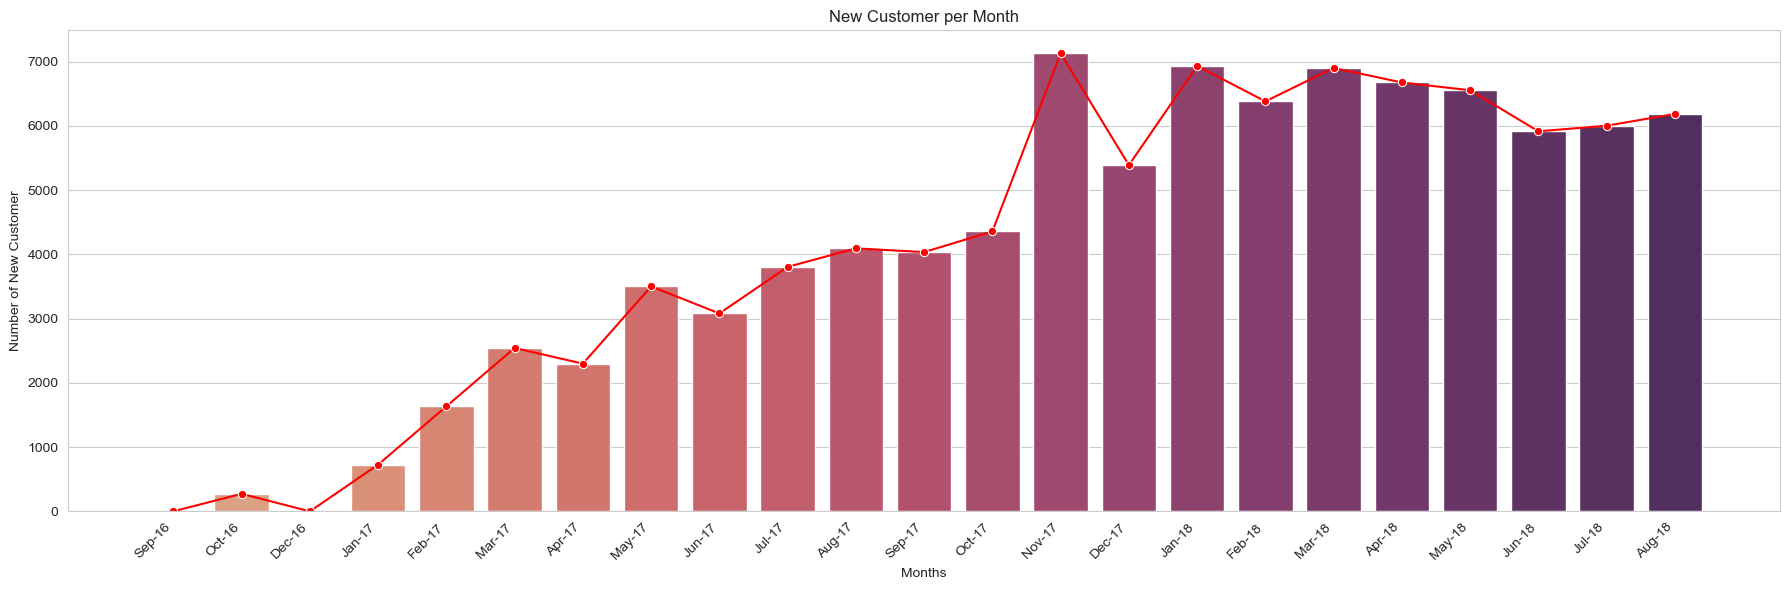

In [301]:
# Finding number of new customer acquired every month

# Merge order data with customer data to get customer unique ID
cust_orders = pd.merge(left = order, right = customer[['customer_id', 'customer_unique_id']], on='customer_id', how='inner')

# Converting Order date month
cust_orders['order_purchase_timestamp'] = pd.to_datetime(cust_orders['order_purchase_timestamp'])

cust_orders['order_month'] = cust_orders['order_purchase_timestamp'].dt.to_period('M')

# Finding first order month for each customer_unique_id
First_purchase_month = cust_orders.groupby('customer_unique_id')['order_month'].min().reset_index()
First_purchase_month.rename(columns={'order_month':'first_purchase_month'}, inplace = True)

# Merge with oroginal data
cust_orders = pd.merge(cust_orders, First_purchase_month, on='customer_unique_id', how='inner')

# Filter customer whose first purchase in that month, if yes then they are new customer
new_customer = cust_orders[cust_orders['order_month'] == cust_orders['first_purchase_month']]

# Count unique new customer per month
count_new_customer = new_customer.groupby('order_month')['customer_unique_id'].nunique().reset_index()
count_new_customer.columns = ['Months', 'New_customer']
display(count_new_customer.T)

# Convert Period to Timestamp, then format it
count_new_customer['Months'] = count_new_customer['Months'].dt.to_timestamp().dt.strftime('%b-%y')

plt.figure(figsize = (18,6))
sns.barplot(count_new_customer, x = 'Months', y = 'New_customer', palette = 'flare')
sns.lineplot(count_new_customer, x = 'Months', y = 'New_customer', marker = 'o', color = 'red')
plt.title('New Customer per Month')
plt.xlabel('Months')
plt.ylabel('Number of New Customer')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [302]:
# This is to verify / ensure data is actually correct

# Pick one customer who has multiple orders
sample_id = cust_orders['customer_unique_id'].value_counts().index[0]

# Check their orders vs their 'first_purchase_month'
print(cust_orders[cust_orders['customer_unique_id'] == sample_id][['order_purchase_timestamp', 'first_purchase_month']])

      order_purchase_timestamp first_purchase_month
2304       2018-08-07 23:32:14              2017-05
3605       2018-05-21 22:44:31              2017-05
5085       2017-09-05 22:14:52              2017-05
11496      2018-08-20 19:14:26              2017-05
18800      2017-07-24 22:11:50              2017-05
24446      2018-05-22 23:08:55              2017-05
33111      2017-07-18 23:10:58              2017-05
38755      2017-11-22 20:01:53              2017-05
57757      2017-08-05 08:59:43              2017-05
65532      2018-08-18 12:39:19              2017-05
67437      2017-05-15 23:30:03              2017-05
68313      2018-07-23 21:53:02              2017-05
75815      2017-06-18 22:56:48              2017-05
80430      2018-07-04 22:35:13              2017-05
83432      2017-10-29 16:58:02              2017-05
95489      2017-10-18 23:25:04              2017-05


order_month,Sep-16,Oct-16,Dec-16,Jan-17,Feb-17,Mar-17,Apr-17,May-17,Jun-17,Jul-17,...,Dec-17,Jan-18,Feb-18,Mar-18,Apr-18,May-18,Jun-18,Jul-18,Aug-18,Sep-18
first_purchase_month,,,,,,,,,,,,,,,,,,,,,
Sep-16,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Oct-16,0.0,275.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,2.0,2.0,0.0,0.0,0.0
Dec-16,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Jan-17,0.0,0.0,0.0,729.0,3.0,2.0,1.0,3.0,1.0,3.0,...,1.0,5.0,3.0,1.0,1.0,2.0,3.0,0.0,1.0,0.0
Feb-17,0.0,0.0,0.0,0.0,1636.0,4.0,5.0,2.0,7.0,2.0,...,2.0,5.0,2.0,3.0,2.0,1.0,1.0,3.0,0.0,0.0
Mar-17,0.0,0.0,0.0,0.0,0.0,2545.0,13.0,9.0,10.0,9.0,...,2.0,9.0,3.0,5.0,3.0,4.0,6.0,2.0,4.0,0.0
Apr-17,0.0,0.0,0.0,0.0,0.0,0.0,2300.0,14.0,5.0,4.0,...,7.0,4.0,6.0,2.0,1.0,1.0,2.0,2.0,3.0,0.0
May-17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3503.0,17.0,17.0,...,5.0,9.0,10.0,9.0,12.0,9.0,1.0,7.0,8.0,0.0
Jun-17,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3082.0,14.0,...,11.0,7.0,4.0,7.0,9.0,10.0,5.0,4.0,6.0,0.0


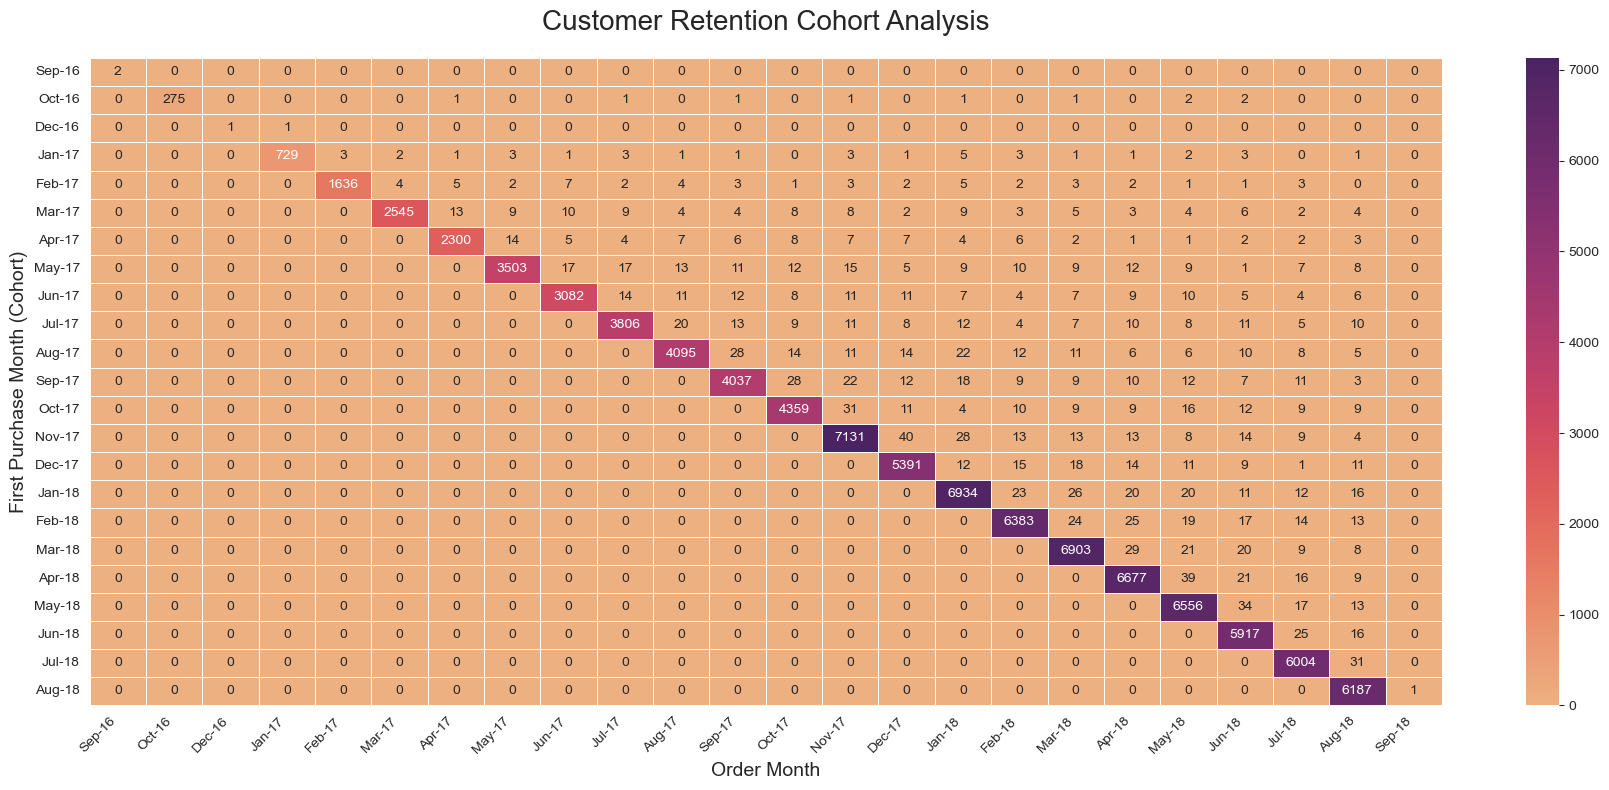

In [303]:
# Finding the repeated customer after their first purchase.

repeated_customer = cust_orders.groupby(['first_purchase_month', 'order_month'])['customer_unique_id'].nunique().unstack().fillna(0)

# Convert Period to Timestamp, then format it
# 1. Format the Index (First Purchase Month) to 'Jan-17'
repeated_customer.index = repeated_customer.index.to_timestamp().strftime('%b-%y')

# 2. Format the Columns (Order Month) to 'Jan-17'
repeated_customer.columns = repeated_customer.columns.to_timestamp().strftime('%b-%y')

display(repeated_customer)

plt.figure(figsize=(18, 8))
sns.heatmap(repeated_customer, annot = True, fmt='.0f', cmap = "flare", linewidths=.5)
plt.title('Customer Retention Cohort Analysis', fontsize=20, pad=20)
plt.xlabel('Order Month', fontsize=14)
plt.ylabel('First Purchase Month (Cohort)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [304]:
# Simple Total Revenue (Price Only)
total_revenue = order_item["price"].sum()
display(f'Total Revenue : {total_revenue:0.2f}')

# Comprehensive Revenue (Including Freight)
total_transition_value = order_item["price"].sum() + order_item["freight_value"].sum()
display(f'Total Revenue (Including Total Cost) : {total_transition_value:0.2f}')

'Total Revenue : 13591297.74'

'Total Revenue (Including Total Cost) : 15843055.04'

In [305]:
# Finding revenue from customers on month basis

# Add column defining new & repeated customer in customer_order table
cust_orders['customer_type'] = np.where(cust_orders['order_month']==cust_orders['first_purchase_month'],'new_customer','repeated customer')

# Add new column in order_item data for total cost of products
order_item['total_pr.cost'] = order_item['freight_value'] + order_item['price']

# Merging customer_order data with order_item into a new dataframe name order_data
order_data = pd.merge(cust_orders[['order_id','customer_id', 'customer_unique_id', 'order_month', 'customer_type']], 
                      order_item[['order_id', 'total_pr.cost']], 
                      on = 'order_id', 
                      how = 'left')

# finding monthly 
monthly_revenue = order_data.groupby(['order_month','customer_type'])['total_pr.cost'].sum().unstack().fillna(0).reset_index()
display(monthly_revenue)

customer_type,order_month,new_customer,repeated customer
0,2016-09,279.69,0.00
1,2016-10,48364.17,0.00
2,2016-12,19.62,0.00
3,2017-01,130312.27,19.62
4,2017-02,273491.37,170.83
5,2017-03,418198.32,650.82
6,2017-04,394712.73,2566.60
7,2017-05,570335.13,5039.10
8,2017-06,489913.72,5979.56
9,2017-07,567066.66,7870.49


In [306]:
plt.close('all')

In [307]:
monthly_revenue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype    
---  ------             --------------  -----    
 0   order_month        24 non-null     period[M]
 1   new_customer       24 non-null     float64  
 2   repeated customer  24 non-null     float64  
dtypes: float64(2), period[M](1)
memory usage: 708.0 bytes


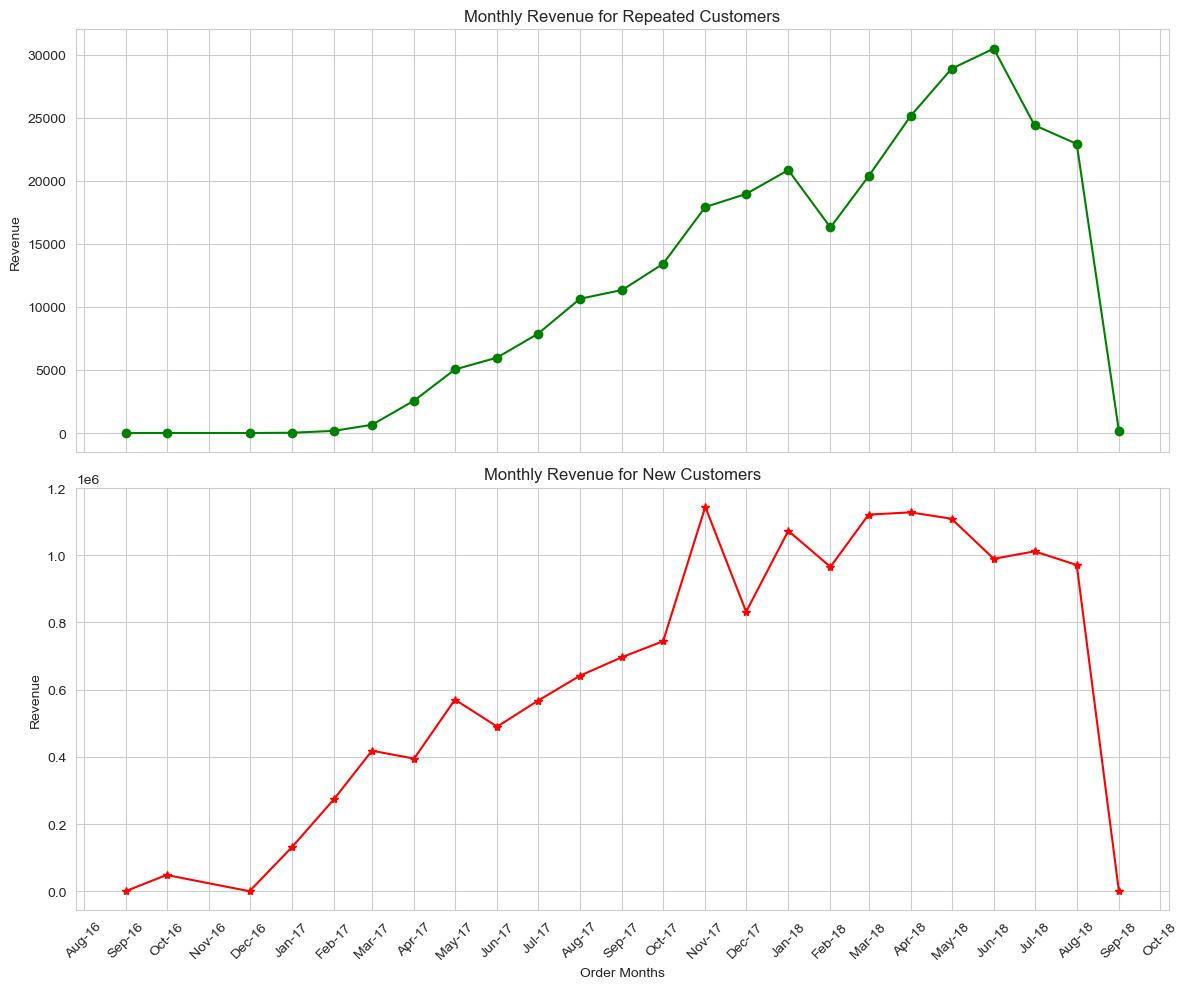

In [308]:
# 1. Clean the data correctly
# We convert to datetime first to ensure chronological order
monthly_revenue['order_month'] = monthly_revenue['order_month'].dt.to_timestamp()
monthly_revenue = monthly_revenue.sort_values('order_month')

# 2. Create the Figure
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# 3. Plotting (We use the datetime objects directly for the X-axis)
axes[0].plot(monthly_revenue['order_month'], monthly_revenue['repeated customer'], 
             color='green', marker='o', linestyle='-')
axes[0].set_title('Monthly Revenue for Repeated Customers')
axes[0].set_ylabel('Revenue')

axes[1].plot(monthly_revenue['order_month'], monthly_revenue['new_customer'], 
             color='red', marker='*', linestyle='-')
axes[1].set_title('Monthly Revenue for New Customers')
axes[1].set_ylabel('Revenue')
axes[1].set_xlabel('Order Months')

# 4. Make the dates look pretty on the X-axis without breaking the logic
import matplotlib.dates as mdates
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b-%y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=45) # Rotate so they don't overlap

plt.tight_layout()
plt.show()

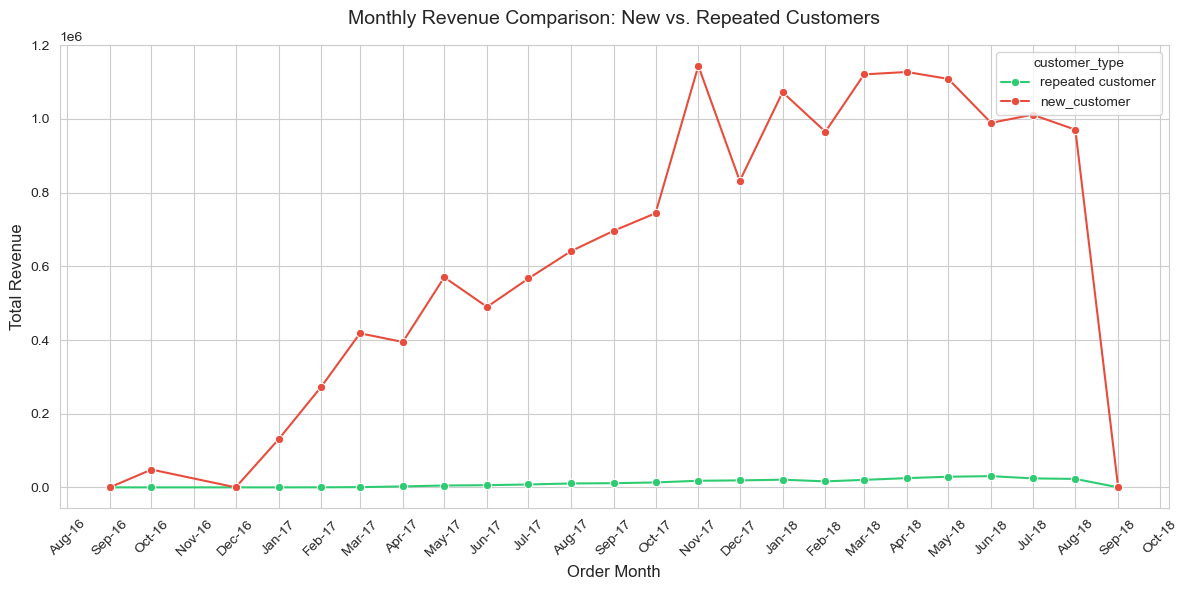

In [309]:
monthly_revenue['order_month'] = pd.to_datetime(monthly_revenue['order_month'], format='%b-%y')
monthly_revenue = monthly_revenue.sort_values('order_month')

# # Only melt the two columns we want to compare
monthly_rev_melt = monthly_revenue.melt(
    id_vars='order_month', 
    value_vars=['repeated customer', 'new_customer'], # Explicitly select these
    var_name='customer_type', 
    value_name='total_revenue'
)

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid") # Adds a clean background grid

ax = sns.lineplot(
    data=monthly_rev_melt, 
    x='order_month', 
    y='total_revenue', 
    hue='customer_type', 
    marker='o',
    palette=['#2ecc71', '#e74c3c'] # Optional: Custom green and red colors
)

# 4. Force Date Formatting
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())

plt.title('Monthly Revenue Comparison: New vs. Repeated Customers', fontsize=14, pad=15)
plt.xlabel('Order Month', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [310]:
payments = order_payments.groupby(['order_id', 'payment_sequential', 'payment_type', 'payment_installments'])['payment_value'].sum().reset_index()
payments

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,credit_card,2,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,credit_card,3,259.83
2,000229ec398224ef6ca0657da4fc703e,1,credit_card,5,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,credit_card,2,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,credit_card,3,218.04
...,...,...,...,...,...
103881,fffc94f6ce00a00581880bf54a75a037,1,boleto,1,343.40
103882,fffcd46ef2263f404302a634eb57f7eb,1,boleto,1,386.53
103883,fffce4705a9662cd70adb13d4a31832d,1,credit_card,3,116.85
103884,fffe18544ffabc95dfada21779c9644f,1,credit_card,3,64.71


In [311]:
# Understand the trend of sales, quantity by category, location, month, week day, time channel 

# 1. Converting the column to datetime first
order['order_purchase_timestamp'] = pd.to_datetime(order['order_purchase_timestamp'])

# 2. Now use .dt. to recover from error
order['order_Month'] = order['order_purchase_timestamp'].dt.to_period('M')
order['year_week'] = order['order_purchase_timestamp'].dt.strftime('%Y-%U')
order['order_day'] = order['order_purchase_timestamp'].dt.day_name()
order['order_hour'] = order['order_purchase_timestamp'].dt.hour

# Join order and order item data to get total products which are ordered to sell
order_items = pd.merge(
    order, order_item, 
    how = "inner", 
    on = "order_id")

# Join order_items and products data to get product category name

order_items_products = pd.merge(
    order_items , 
    products [['product_id', 'product_category_name']], 
    how = 'inner', 
    on = 'product_id')

# Join order_items_products and customer data to get customer related location in a data frame

odr_itm_prd_cus = pd.merge(
    order_items_products, customer[['customer_id','customer_city', 'customer_state']], 
    how = 'inner', 
    on = 'customer_id')



In [312]:
# Checking null value after Joining in new data set
display(order_items_products.isnull().sum().sum())
display('--'*35)
display(odr_itm_prd_cus.isnull().sum().sum())

0

'----------------------------------------------------------------------'

0

In [313]:
order_items_products['product_category_name'] = order_items_products['product_category_name'].fillna('unknown')
odr_itm_prd_cus['product_category_name'] = odr_itm_prd_cus['product_category_name'].fillna('unknown')

In [314]:
order_items_products.isna().sum().sum()

0

In [315]:
# Total number of product entries (sales transactions) per category per month

total_category_qty = pd.pivot_table(
    order_items_products, 
    values='product_id', 
    index='product_category_name', 
    columns='order_Month', 
    margins = True, 
    margins_name = 'Grand Total', 
    aggfunc = 'count',
    ).fillna(0)
print('Total quantity sold by category per month : \n')
display(total_category_qty)

Total quantity sold by category per month : 



order_Month,2016-09,2016-10,2016-12,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,...,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08,2018-09,Grand Total
product_category_name,,,,,,,,,,,,,,,,,,,,,
agro_industria_e_comercio,0.0,0.0,0.0,3.0,7.0,2.0,0.0,4.0,1.0,1.0,...,18.0,26.0,28.0,12.0,8.0,10.0,30.0,18.0,0.0,211
alimentos,0.0,1.0,0.0,2.0,8.0,22.0,8.0,3.0,1.0,7.0,...,19.0,39.0,35.0,40.0,44.0,24.0,64.0,116.0,0.0,505
alimentos_bebidas,0.0,0.0,0.0,0.0,0.0,4.0,3.0,12.0,2.0,8.0,...,11.0,24.0,19.0,18.0,25.0,11.0,17.0,21.0,0.0,271
artes,0.0,0.0,0.0,0.0,0.0,5.0,1.0,7.0,4.0,3.0,...,19.0,12.0,7.0,26.0,36.0,28.0,21.0,18.0,0.0,201
artes_e_artesanato,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,11.0,9.0,0.0,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tablets_impressao_imagem,0.0,0.0,0.0,0.0,8.0,5.0,11.0,7.0,6.0,2.0,...,3.0,13.0,3.0,1.0,1.0,1.0,0.0,0.0,0.0,83
telefonia,0.0,8.0,0.0,23.0,106.0,168.0,144.0,220.0,159.0,144.0,...,371.0,359.0,343.0,283.0,252.0,218.0,223.0,273.0,0.0,4490
telefonia_fixa,0.0,5.0,0.0,22.0,22.0,20.0,6.0,10.0,12.0,9.0,...,10.0,11.0,14.0,11.0,16.0,17.0,11.0,10.0,0.0,256


In [316]:
# Total sales per Category per month

Total_category_qty = pd.pivot_table(order_items_products, 
    values='price', 
    index='product_category_name', 
    columns='order_Month', 
    margins = True, 
    margins_name = 'Grand Total', 
    aggfunc = 'sum',
    ).fillna(0)
print('Total sales by Category per month : \n')
display(total_category_qty)

Total sales by Category per month : 



order_Month,2016-09,2016-10,2016-12,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,...,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08,2018-09,Grand Total
product_category_name,,,,,,,,,,,,,,,,,,,,,
agro_industria_e_comercio,0.0,0.0,0.0,3.0,7.0,2.0,0.0,4.0,1.0,1.0,...,18.0,26.0,28.0,12.0,8.0,10.0,30.0,18.0,0.0,211
alimentos,0.0,1.0,0.0,2.0,8.0,22.0,8.0,3.0,1.0,7.0,...,19.0,39.0,35.0,40.0,44.0,24.0,64.0,116.0,0.0,505
alimentos_bebidas,0.0,0.0,0.0,0.0,0.0,4.0,3.0,12.0,2.0,8.0,...,11.0,24.0,19.0,18.0,25.0,11.0,17.0,21.0,0.0,271
artes,0.0,0.0,0.0,0.0,0.0,5.0,1.0,7.0,4.0,3.0,...,19.0,12.0,7.0,26.0,36.0,28.0,21.0,18.0,0.0,201
artes_e_artesanato,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,11.0,9.0,0.0,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tablets_impressao_imagem,0.0,0.0,0.0,0.0,8.0,5.0,11.0,7.0,6.0,2.0,...,3.0,13.0,3.0,1.0,1.0,1.0,0.0,0.0,0.0,83
telefonia,0.0,8.0,0.0,23.0,106.0,168.0,144.0,220.0,159.0,144.0,...,371.0,359.0,343.0,283.0,252.0,218.0,223.0,273.0,0.0,4490
telefonia_fixa,0.0,5.0,0.0,22.0,22.0,20.0,6.0,10.0,12.0,9.0,...,10.0,11.0,14.0,11.0,16.0,17.0,11.0,10.0,0.0,256


In [317]:
# Quantity sold by location per month

qty_by_location = pd.pivot_table(
    odr_itm_prd_cus, 
    values = 'product_id', 
    index = 'customer_state', 
    columns = 'order_Month', 
    aggfunc = 'count', 
    margins = True, 
    margins_name = 'Grand Total', 
    fill_value = 0 
    )
print('Total product sold by location per month : \n')
display(total_category_qty)

Total product sold by location per month : 



order_Month,2016-09,2016-10,2016-12,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,...,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08,2018-09,Grand Total
product_category_name,,,,,,,,,,,,,,,,,,,,,
agro_industria_e_comercio,0.0,0.0,0.0,3.0,7.0,2.0,0.0,4.0,1.0,1.0,...,18.0,26.0,28.0,12.0,8.0,10.0,30.0,18.0,0.0,211
alimentos,0.0,1.0,0.0,2.0,8.0,22.0,8.0,3.0,1.0,7.0,...,19.0,39.0,35.0,40.0,44.0,24.0,64.0,116.0,0.0,505
alimentos_bebidas,0.0,0.0,0.0,0.0,0.0,4.0,3.0,12.0,2.0,8.0,...,11.0,24.0,19.0,18.0,25.0,11.0,17.0,21.0,0.0,271
artes,0.0,0.0,0.0,0.0,0.0,5.0,1.0,7.0,4.0,3.0,...,19.0,12.0,7.0,26.0,36.0,28.0,21.0,18.0,0.0,201
artes_e_artesanato,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,11.0,9.0,0.0,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tablets_impressao_imagem,0.0,0.0,0.0,0.0,8.0,5.0,11.0,7.0,6.0,2.0,...,3.0,13.0,3.0,1.0,1.0,1.0,0.0,0.0,0.0,83
telefonia,0.0,8.0,0.0,23.0,106.0,168.0,144.0,220.0,159.0,144.0,...,371.0,359.0,343.0,283.0,252.0,218.0,223.0,273.0,0.0,4490
telefonia_fixa,0.0,5.0,0.0,22.0,22.0,20.0,6.0,10.0,12.0,9.0,...,10.0,11.0,14.0,11.0,16.0,17.0,11.0,10.0,0.0,256


In [318]:
# Total sales by location per month

sales_by_location = pd.pivot_table(
    odr_itm_prd_cus, 
    values = 'price', 
    index = 'customer_state', 
    columns = 'order_Month', 
    aggfunc = 'sum', 
    margins = True, 
    margins_name = 'Grand Total', 
    fill_value = 0 
    )
print('Total sales by location per month : \n')
display(total_category_qty)

Total sales by location per month : 



order_Month,2016-09,2016-10,2016-12,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,...,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08,2018-09,Grand Total
product_category_name,,,,,,,,,,,,,,,,,,,,,
agro_industria_e_comercio,0.0,0.0,0.0,3.0,7.0,2.0,0.0,4.0,1.0,1.0,...,18.0,26.0,28.0,12.0,8.0,10.0,30.0,18.0,0.0,211
alimentos,0.0,1.0,0.0,2.0,8.0,22.0,8.0,3.0,1.0,7.0,...,19.0,39.0,35.0,40.0,44.0,24.0,64.0,116.0,0.0,505
alimentos_bebidas,0.0,0.0,0.0,0.0,0.0,4.0,3.0,12.0,2.0,8.0,...,11.0,24.0,19.0,18.0,25.0,11.0,17.0,21.0,0.0,271
artes,0.0,0.0,0.0,0.0,0.0,5.0,1.0,7.0,4.0,3.0,...,19.0,12.0,7.0,26.0,36.0,28.0,21.0,18.0,0.0,201
artes_e_artesanato,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,11.0,9.0,0.0,24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tablets_impressao_imagem,0.0,0.0,0.0,0.0,8.0,5.0,11.0,7.0,6.0,2.0,...,3.0,13.0,3.0,1.0,1.0,1.0,0.0,0.0,0.0,83
telefonia,0.0,8.0,0.0,23.0,106.0,168.0,144.0,220.0,159.0,144.0,...,371.0,359.0,343.0,283.0,252.0,218.0,223.0,273.0,0.0,4490
telefonia_fixa,0.0,5.0,0.0,22.0,22.0,20.0,6.0,10.0,12.0,9.0,...,10.0,11.0,14.0,11.0,16.0,17.0,11.0,10.0,0.0,256


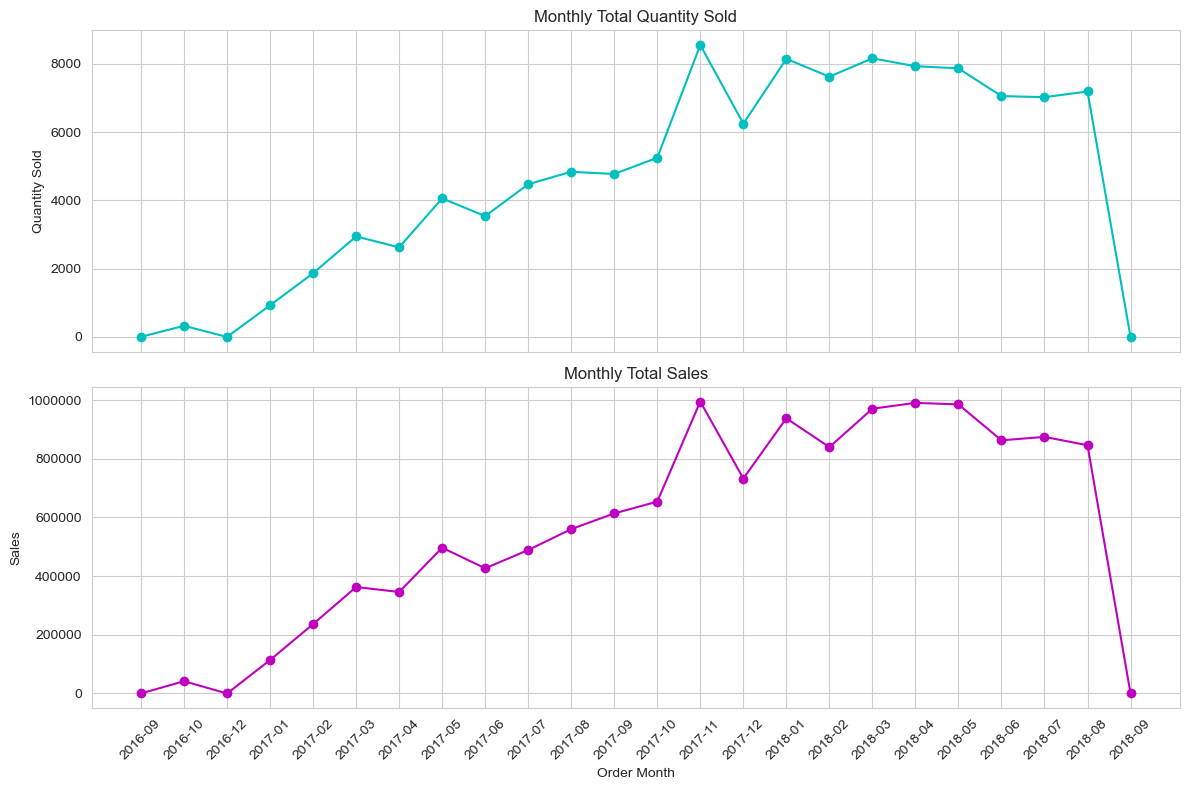

In [319]:
# Monthly Trends

monthly_trends = order_items.groupby('order_Month').agg(quantity=('product_id', 'count'), total_sales = ('price', "sum")).reset_index()

monthly_trends['order_Month'] = monthly_trends['order_Month'].astype(str)

# Visualization

fig, axes = plt.subplots(2,1, figsize = (12,8), sharex = True)

axes[0].plot(monthly_trends.order_Month, monthly_trends['quantity'], color = 'c', marker='o')
axes[0].set_title('Monthly Total Quantity Sold')
axes[0].set_ylabel('Quantity Sold')
axes[0].ticklabel_format(style='plain', axis='y')

axes[1].plot(monthly_trends.order_Month, monthly_trends['total_sales'], color = 'm', marker='o')
axes[1].set_title('Monthly Total Sales')
axes[1].set_xlabel('Order Month')
axes[1].set_ylabel('Sales')
axes[1].ticklabel_format(style='plain', axis='y')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

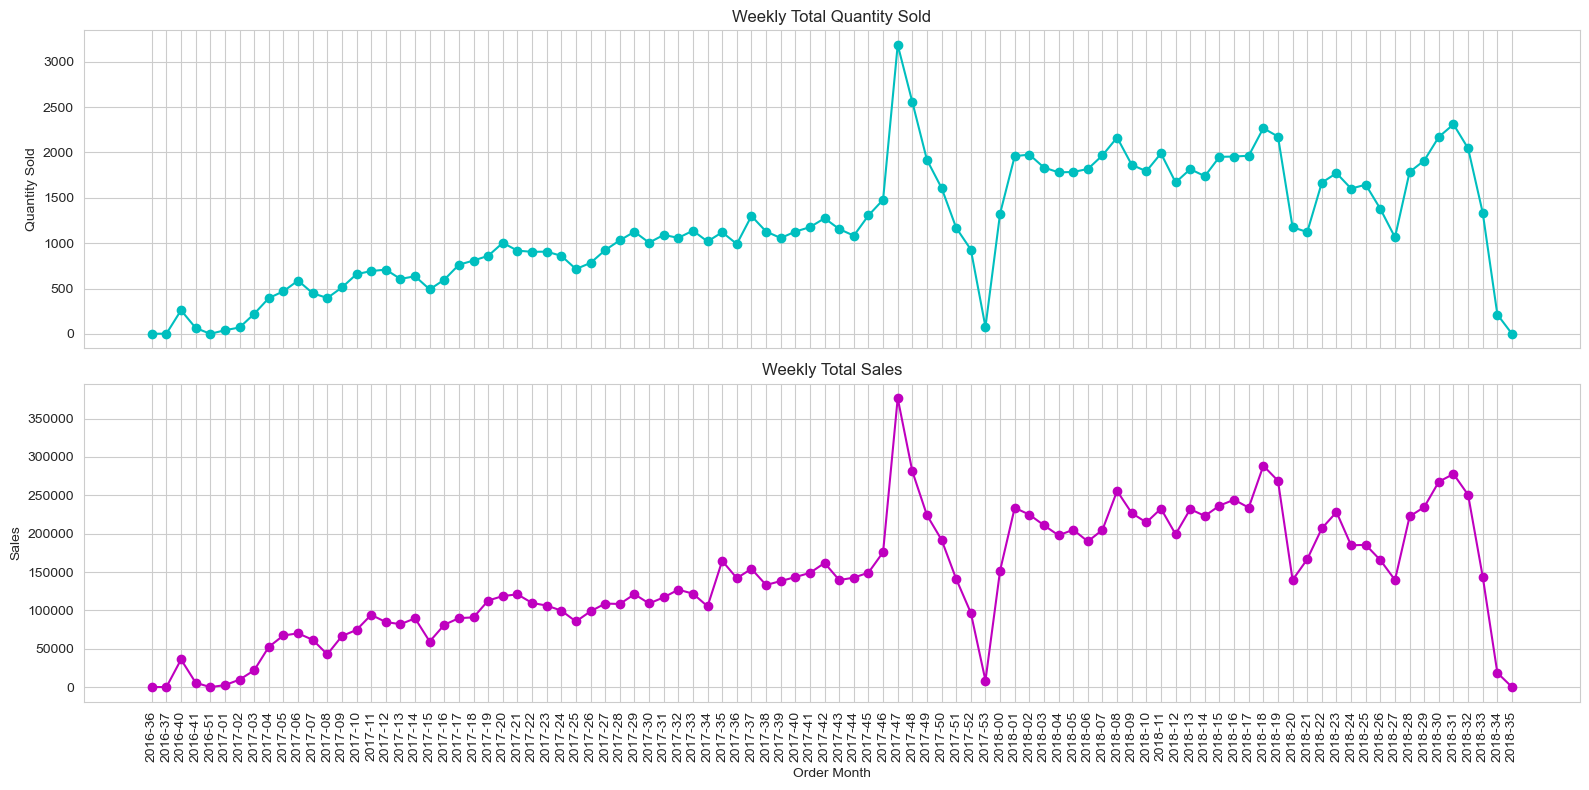

In [320]:
# Weekly trend 

weekly_trends = order_items.groupby('year_week').agg(quantity=('product_id', 'count'), total_sales = ('price', "sum")).reset_index()

weekly_trends['year_week'] = weekly_trends['year_week'].astype(str)

# Visualization

fig, axes = plt.subplots(2,1, figsize = (16,8), sharex = True)

axes[0].plot(weekly_trends.year_week, weekly_trends['quantity'], color = 'c', marker='o')
axes[0].set_title('Weekly Total Quantity Sold')
axes[0].set_ylabel('Quantity Sold')
axes[0].ticklabel_format(style='plain', axis='y')

axes[1].plot(weekly_trends.year_week, weekly_trends['total_sales'], color = 'm', marker='o')
axes[1].set_title('Weekly Total Sales')
axes[1].set_xlabel('Order Month')
axes[1].set_ylabel('Sales')
axes[1].ticklabel_format(style='plain', axis='y')

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


 Overall Total quantity sold by day of week :



order_day,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
year_week,,,,,,,
2016-36,0.0,0.0,0.0,0.0,0.0,0.0,2.0
2016-37,0.0,0.0,0.0,3.0,0.0,0.0,0.0
2016-40,8.0,64.0,51.0,47.0,49.0,42.0,0.0
2016-41,37.0,0.0,0.0,0.0,0.0,0.0,29.0
2016-51,0.0,0.0,0.0,0.0,1.0,0.0,0.0



 Overall Total Sales by day of week :



order_day,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
year_week,,,,,,,
2016-36,0.00,0.00,0.00,0.00,0.00,0.00,72.89
2016-37,0.00,0.00,0.00,134.97,0.00,0.00,0.00
2016-40,463.48,8618.26,6589.56,5889.96,6792.65,7692.88,0.00
2016-41,3159.57,0.00,0.00,0.00,0.00,0.00,2644.50
2016-51,0.00,0.00,0.00,0.00,10.90,0.00,0.00


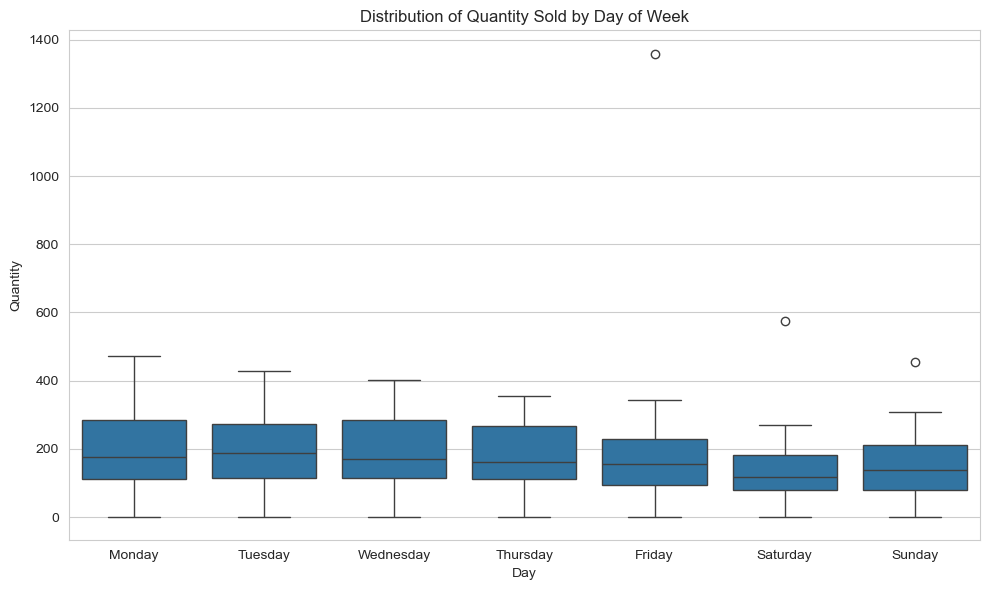

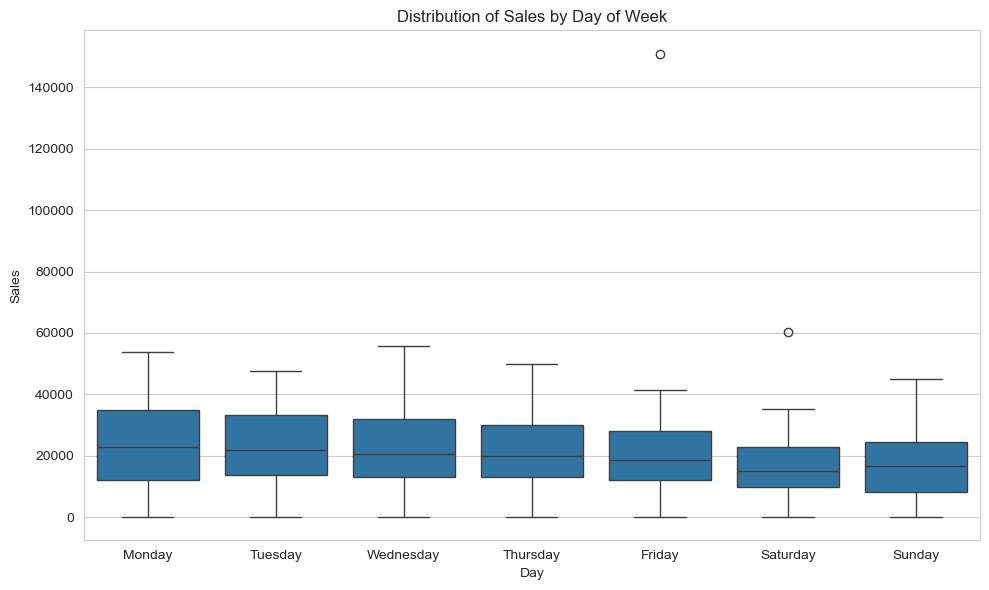

In [321]:
# By day of week trends

weekly_qty_sold = order_items.groupby(['year_week', 'order_day'])['product_id'].count().unstack().fillna(0)
print('\n Overall Total quantity sold by day of week :\n')
weekday_order = ['Monday', 'Tuesday', 'Wednesday','Thursday','Friday', 'Saturday', 'Sunday']
display(weekly_qty_sold[weekday_order].head())

weekly_sales = order_items.groupby(['year_week', 'order_day'])['price'].sum().unstack().fillna(0)
print('\n Overall Total Sales by day of week :\n')
display(weekly_sales[weekday_order].head())

qty_melted = weekly_qty_sold[weekday_order].reset_index().melt(id_vars = 'year_week', 
                                                             var_name = 'Day',
                                                             value_name ='Quantity'
                                                             )

sales_melted = weekly_sales[weekday_order].reset_index().melt(id_vars = 'year_week', 
                                                             var_name = 'Day',
                                                             value_name ='Sales'
                                                             )

plt.figure(figsize=(10,6))
sns.boxplot(qty_melted, x='Day', y='Quantity')
plt.title('Distribution of Quantity Sold by Day of Week')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(sales_melted, x='Day', y='Sales')
plt.title('Distribution of Sales by Day of Week')
plt.tight_layout()
plt.show()


,order_hour,quantity,total_sales
0,0,2688,311469.20
1,1,1275,148734.82
2,2,579,54481.23
3,3,310,34621.71
4,4,243,24261.60
5,5,214,21925.21
6,6,545,55988.50
7,7,1359,149016.39
8,8,3355,389613.44
9,9,5394,672751.75


C:\Users\user\AppData\Local\Temp\ipykernel_14560\3482520895.py:17: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x='order_hour', y='total_sales',data = hourly_trends, palette='mako', ax=ax2)


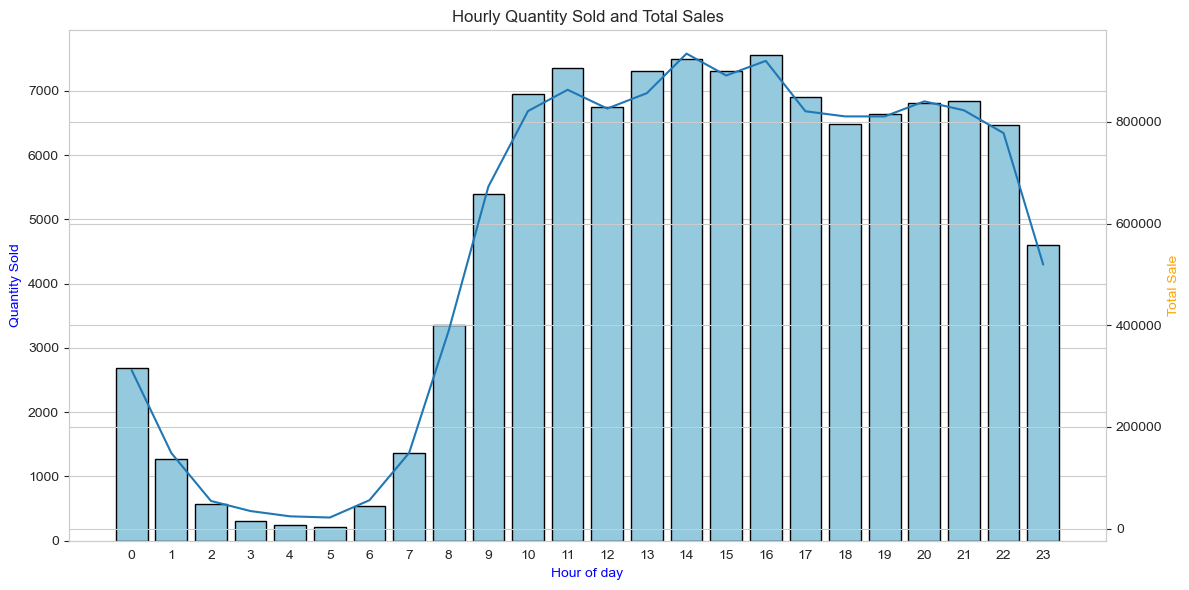

In [322]:
# Hourly Trends

hourly_trends = order_items.groupby('order_hour').agg(quantity=('product_id', 'count'), total_sales = ('price', "sum")).reset_index()
hourly_trends = hourly_trends.sort_values(by='order_hour', ascending = True, ignore_index = True)
display(hourly_trends)

fix, ax1 = plt.subplots(figsize=(12,6))

# Bar for Quantity
sns.barplot(x='order_hour', y='quantity',data = hourly_trends, color='skyblue', ax=ax1, edgecolor="black")
ax1.set_xlabel('Hour of day', color = 'blue')
ax1.set_ylabel('Quantity Sold', color = 'blue')
ax1.set_title('Hourly Quantity Sold and Total Sales')

# Twin axis for sales
ax2 = ax1.twinx()
sns.lineplot(x='order_hour', y='total_sales',data = hourly_trends, palette='mako', ax=ax2)
ax2.set_ylabel('Total Sale', color = 'orange')

plt.tight_layout()
plt.show()

In [323]:
# Indentifying popular products

odr_itm_prd_cus['order_pur_month'] = odr_itm_prd_cus['order_purchase_timestamp'].dt.to_period('M')

products_data = odr_itm_prd_cus.drop(columns=['order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date','order_Month', 'year_week', 'order_day', 'order_hour','shipping_limit_date'],
                                     errors = 'ignore')

In [324]:
# Popular products by month
pp_products_months = products_data.groupby(['order_pur_month', 'product_id']).size().reset_index(name='units_sold')

# Sort highest sales at the top of each month
pp_products_months = pp_products_months.sort_values(['order_pur_month', 'units_sold'], ascending = [True, False], ignore_index = True)

# Get only top n top products per month
pp_products_months = pp_products_months.groupby('order_pur_month').head(5).reset_index(drop=True)
pp_products_months

# Pie Chart


,order_pur_month,product_id,units_sold
0,2016-09,5a6b04657a4c5ee34285d1e4619a96b4,3
1,2016-09,c1488892604e4ba5cff5b4eb4d595400,1
2,2016-09,f293394c72c9b5fafd7023301fc21fc2,1
3,2016-10,eba7488e1c67729f045ab43fac426f2e,10
4,2016-10,d9894482fba41f536a273ba2276d951f,6
...,...,...,...
105,2018-08,73326828aa5efe1ba096223de496f596,54
106,2018-08,19c91ef95d509ea33eda93495c4d3481,32
107,2018-08,3fbc0ef745950c7932d5f2a446189725,28
108,2018-08,a92930c327948861c015c919a0bcb4a8,28


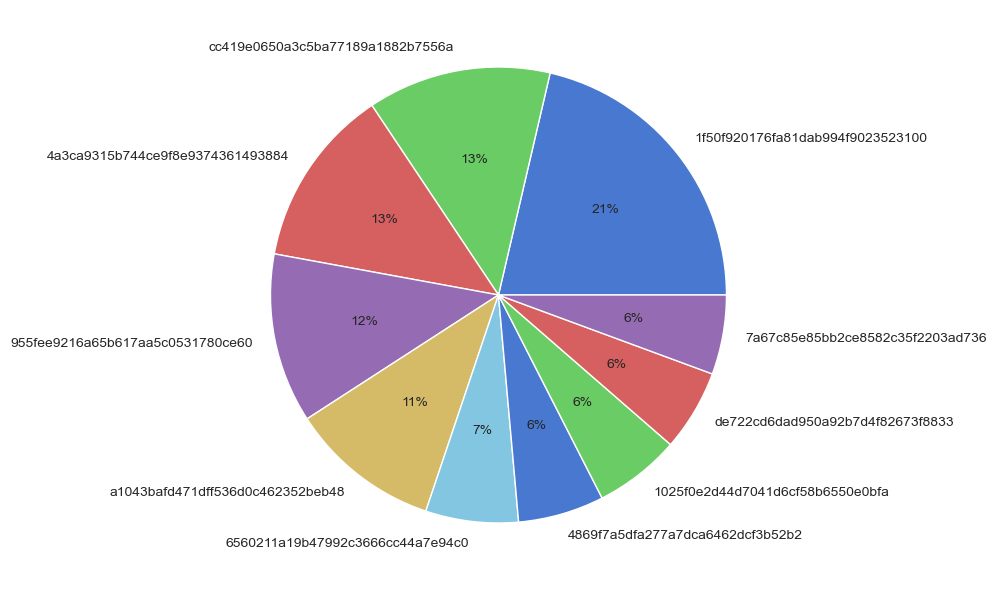

In [325]:
# Top 5 products per seller

pp_products_seller = (
    products_data
    .groupby(['seller_id', 'product_id'])
    .size()
    .reset_index(name='units_sold')
    .sort_values(['seller_id', 'units_sold'], ascending=[True, False])
    .groupby('seller_id')
    .head(3)
)

# Aggregate Sellers
seller_sales = pp_products_seller.groupby("seller_id")["units_sold"].sum()

# Top sellers
top_10_sellers = seller_sales.sort_values(ascending = False).head(10)

# Pie Chart

colors = sns.color_palette('muted6')

plt.figure(figsize=(10,6))
plt.pie(top_10_sellers, labels = top_10_sellers.index, colors = colors, autopct='%.0f%%')

plt.tight_layout()
plt.show()



  customer_state                        product_id  units_sold
0             AC  b81a05d0dd312ece2140846909f5ef81           6
1             AC  3a8bbcf3084a3e388588a1b43e188d81           3
2             AC  42fffc68ff7e8176f11baaf4a4227557           2
3             AC  6cc859e89d080218ff4416539ffa030c           2
4             AC  d696750e550fd0f733979dd7e5dff921           2


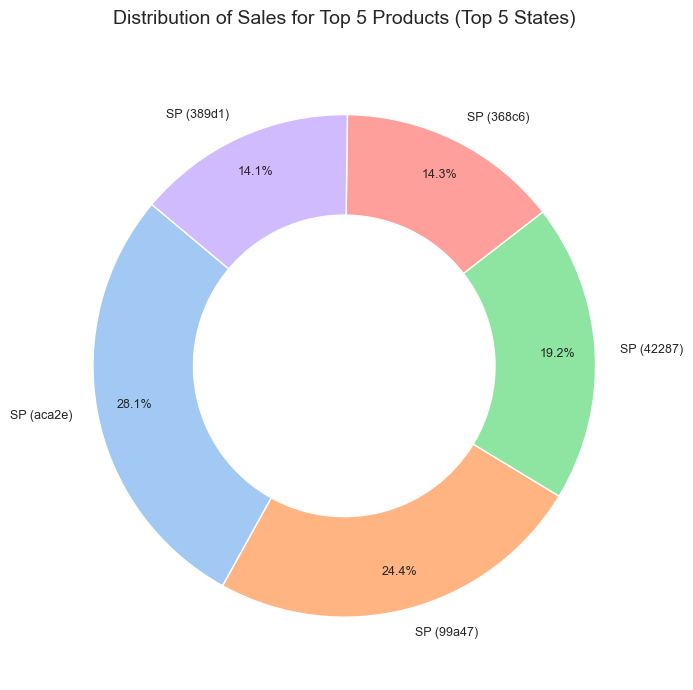

In [326]:
# The Top 5 Best Selling Items by Region

pp_products_st = (
    products_data
    .groupby(['customer_state', 'product_id'])
    .size()
    .reset_index(name='units_sold')
)

# sort higest at top 

pp_products_st = pp_products_st.sort_values(
    by=['customer_state', 'units_sold'],
ascending=[True, False],
ignore_index=True
)
# top 5 products per state

pp_products_st = pp_products_st.groupby('customer_state').head(5).reset_index(drop=True)
print(pp_products_st.head(5))


# 1. Use the aggregated Top 5 data
# (Make sure top_5_state is defined as the Series)
data_to_plot = pp_products_st.nlargest(5, 'units_sold') 

# 2. Create a unique label for each slice (e.g., "SP - Product_123")
# This prevents different products from the same state having the same label
chart_labels = data_to_plot['customer_state'] + " (" + data_to_plot['product_id'].str[:5] + ")"

# 3. Setup colors
colors = sns.color_palette('pastel', len(data_to_plot))

# 4. Create the plot using subplots
fig, ax = plt.subplots(figsize=(10, 7))

# 5. Plot the donut chart
ax.pie(
    data_to_plot['units_sold'], 
    labels=chart_labels, 
    colors=colors,
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=0.85,
    wedgeprops={"width":0.4, "edgecolor":"white"},
    textprops={'fontsize': 9}
)

plt.title("Distribution of Sales for Top 5 Products (Top 5 States)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

customer_state
AC    15
AL    29
AM    16
AP    14
BA    96
Name: units_sold, dtype: int64


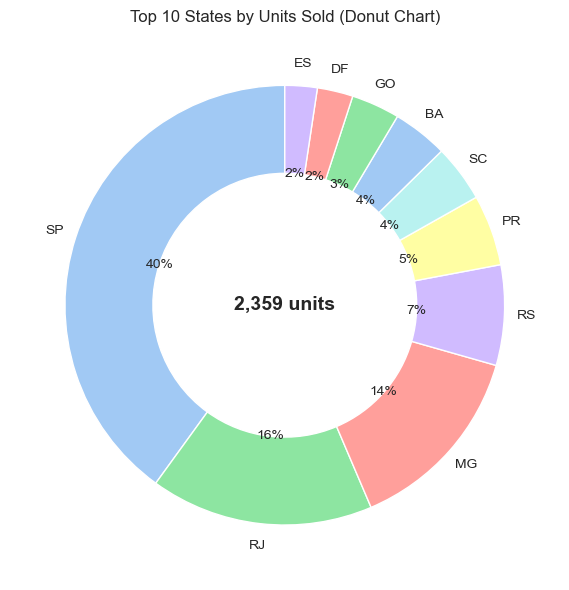

In [327]:
# the combined volume of their top 5 products sold by state

pp_products_state = (
    products_data
    .groupby(['customer_state', 'product_id'])
    .size()
    .reset_index(name='units_sold')
    .sort_values(['customer_state', 'units_sold'], ascending=[True, False])
    .groupby('customer_state')
    .head(5)
)


# Aggregate Sellers
customer_state = pp_products_state.groupby("customer_state")["units_sold"].sum()

print(customer_state.head())

# Top sellers
top_10_state = customer_state.nlargest(10)

# Donut Chart


colors = sns.color_palette('pastel6', 10)

plt.figure(figsize=(10,6))
plt.pie(
    top_10_state,
    labels=top_10_state.index,   # state name
    colors=colors,
    autopct="%d%%",              # show percentages
    startangle=90,
    wedgeprops={"width":0.4, "edgecolor":"white"},       # makes it a donut
    textprops={'ha':'center', 'va':'center'}
)

# Add total units sold in the center
total_units = top_10_state.sum()
plt.text(0, 0, f"{total_units:,} units",
         ha="center", va="center", fontsize=14, weight="bold")

plt.title("Top 10 States by Units Sold (Donut Chart)")
plt.tight_layout()
plt.show()

       product_category_name                        product_id  order_count
0  agro_industria_e_comercio  11250b0d4b709fee92441c5f34122aed           22
1  agro_industria_e_comercio  423a6644f0aa529e8828ff1f91003690           18
2  agro_industria_e_comercio  672e757f331900b9deea127a2a7b79fd           17
3  agro_industria_e_comercio  3bebad3cf2c8d1a8d3ce97174643e054           13
4  agro_industria_e_comercio  a0fe1efb855f3e786f0650268cd77f44           13


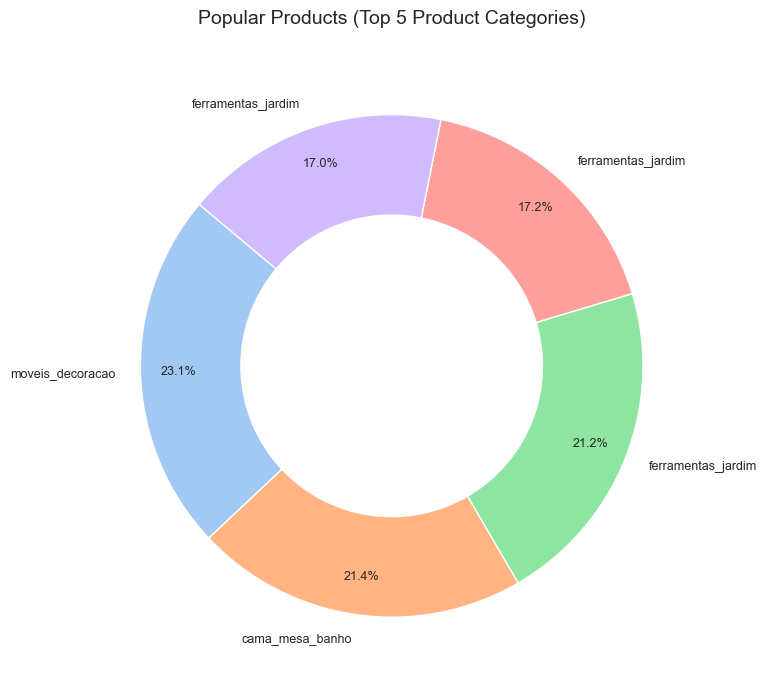

In [328]:
# Popular products by Categoty
pp_by_category = (
    products_data
    .groupby(['product_category_name', 'product_id'])
    .size()
    .reset_index(name='order_count')
)

# sort highest category at top 
pp_by_category = pp_by_category.sort_values(['product_category_name', 'order_count'],
ascending=[True, False],
ignore_index=True
)

# top 5 products of each category
pp_by_category = pp_by_category.groupby('product_category_name').head(5).reset_index(drop=True)
print(pp_by_category.head(5))

# Donut Chart

# 1. Use the aggregated Top 5 data
# (Make sure top_5_state is defined as the Series)
pp_by_category_ser = pp_by_category.nlargest(5, 'order_count')

# 2. Setup colors
colors = sns.color_palette('pastel', len(pp_by_category_ser))

# 4. Create the plot using subplots
fig, ax = plt.subplots(figsize=(10, 7))

# 5. Plot the donut chart
ax.pie(
    pp_by_category_ser['order_count'], 
    labels=pp_by_category_ser['product_category_name'], 
    colors=colors,
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=0.85,
    wedgeprops={"width":0.4, "edgecolor":"white"},
    textprops={'fontsize': 9}
)

plt.title("Popular Products (Top 5 Product Categories)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()


  customer_state   product_category_name  units_sold
0             AC        moveis_decoracao          12
1             AC           esporte_lazer           9
2             AC  informatica_acessorios           9
3             AC            beleza_saude           7
4             AC               telefonia           5


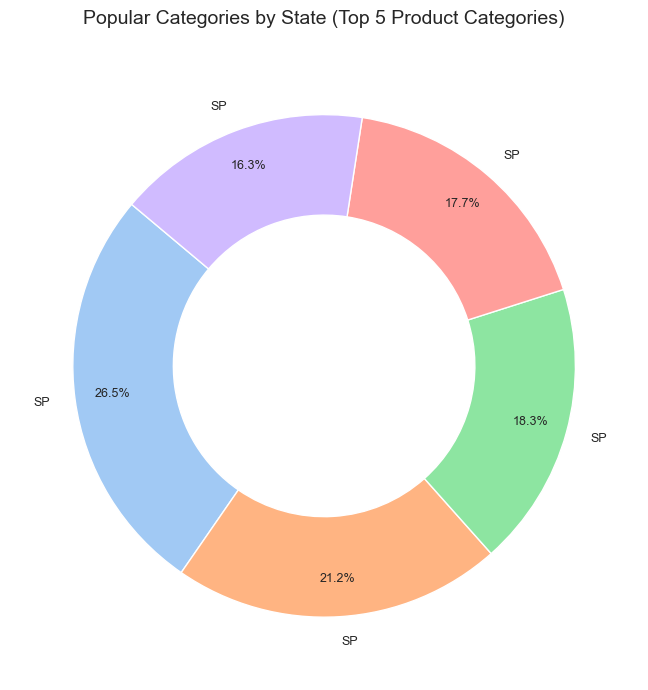

In [329]:
# Popular category by State
pp_category_by_state = (
    products_data
    .groupby(['customer_state', 'product_category_name'])
    .product_id
    .count()
    .reset_index(name='units_sold')
)

# sort data to get popular categories at top 
pp_category_by_state = pp_category_by_state.sort_values(['customer_state', 'units_sold'],
ascending=[True, False],
ignore_index=True
)

# top 5 products of each category
pp_category_by_state = pp_category_by_state.groupby('customer_state').head(5).reset_index(drop=True)
print(pp_category_by_state.head(5))

# Donut Chart

# 1. Use the aggregated Top 5 data
# (Make sure top_5_state is defined as the Series)
pp_category_by_state_ser = pp_category_by_state.nlargest(5, 'units_sold')

# 2. Setup colors
colors = sns.color_palette('pastel', len(pp_category_by_state_ser))

# 4. Create the plot using subplots
fig, ax = plt.subplots(figsize=(10, 7))

# 5. Plot the donut chart
ax.pie(
    pp_category_by_state_ser['units_sold'], 
    labels=pp_category_by_state_ser['customer_state'], 
    colors=colors,
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=0.85,
    wedgeprops={"width":0.4, "edgecolor":"white"},
    textprops={'fontsize': 9}
)

plt.title("Popular Categories by State (Top 5 Product Categories)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

  order_pur_month product_category_name  units_sold
0         2016-09          beleza_saude           3
1         2016-09      moveis_decoracao           2
2         2016-10      moveis_decoracao          66
3         2016-10          beleza_saude          44
4         2016-10            perfumaria          31


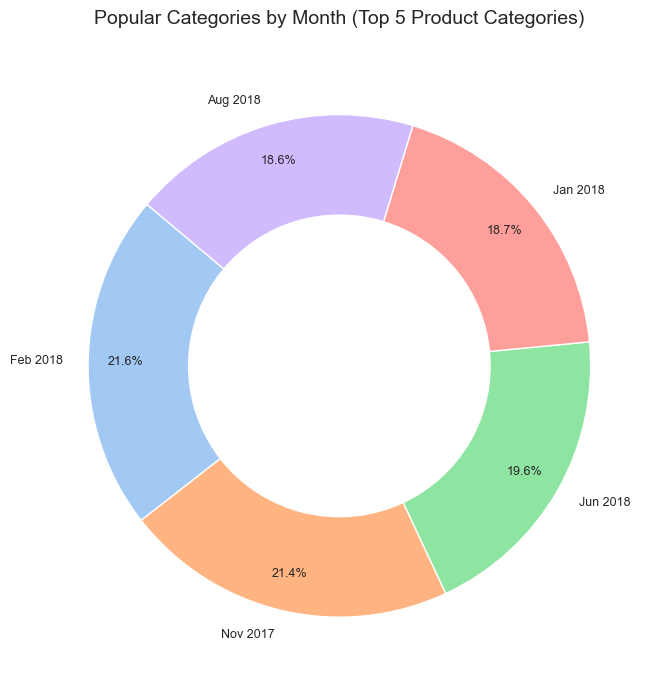

In [330]:
# Popular category by month

pp_category_by_month = (
    products_data
    .groupby(['order_pur_month', 'product_category_name'])
    .product_id
    .count()
    .reset_index(name='units_sold')
)

# sort data to get popular categories at top 
pp_category_by_month = pp_category_by_month.sort_values(['order_pur_month', 'units_sold'],
ascending=[True, False],
ignore_index=True
)

# top 5 products of each category
pp_category_by_month = pp_category_by_month.groupby('order_pur_month').head(5).reset_index(drop=True)
print(pp_category_by_month.head(5))

# Donut Chart

# If order_pur_month is a Period, convert it to timestamp
pp_category_by_month['order_pur_month'] = pp_category_by_month['order_pur_month'].dt.to_timestamp()

# Now create a formatted month name column
pp_category_by_month['month_name'] = pp_category_by_month['order_pur_month'].dt.strftime('%b %Y')

# 1. Use the aggregated Top 5 data
# (Make sure top_5_state is defined as the Series)
pp_category_by_month_ser = pp_category_by_month.nlargest(5, 'units_sold')

# 2. Setup colors
colors = sns.color_palette('pastel', len(pp_category_by_month_ser))

# 4. Create the plot using subplots
fig, ax = plt.subplots(figsize=(10, 7))

# 5. Plot the donut chart
ax.pie(
    pp_category_by_month_ser['units_sold'], 
    labels=pp_category_by_month_ser['month_name'], 
    colors=colors,
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=0.85,
    wedgeprops={"width":0.4, "edgecolor":"white"},
    textprops={'fontsize': 9}
)

plt.title("Popular Categories by Month (Top 5 Product Categories)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

,product_id,product_category_name,avg_price
0,489ae2aa008f021502940f251d4cce7f,utilidades_domesticas,6735.00
1,69c590f7ffc7bf8db97190b6cb6ed62e,pcs,6729.00
2,1bdf5e6731585cf01aa8169c7028d6ad,artes,6499.00
3,a6492cc69376c469ab6f61d8f44de961,eletroportateis,4799.00
4,c3ed642d592594bb648ff4a04cee2747,eletroportateis,4690.00
5,259037a6a41845e455183f89c5035f18,pcs,4590.00
6,a1beef8f3992dbd4cd8726796aa69c53,instrumentos_musicais,4399.87
7,6cdf8fc1d741c76586d8b6b15e9eef30,consoles_games,4099.99
8,6902c1962dd19d540807d0ab8fade5c6,relogios_presentes,3999.90
9,4ca7b91a31637bd24fb8e559d5e015e4,eletroportateis,3999.00


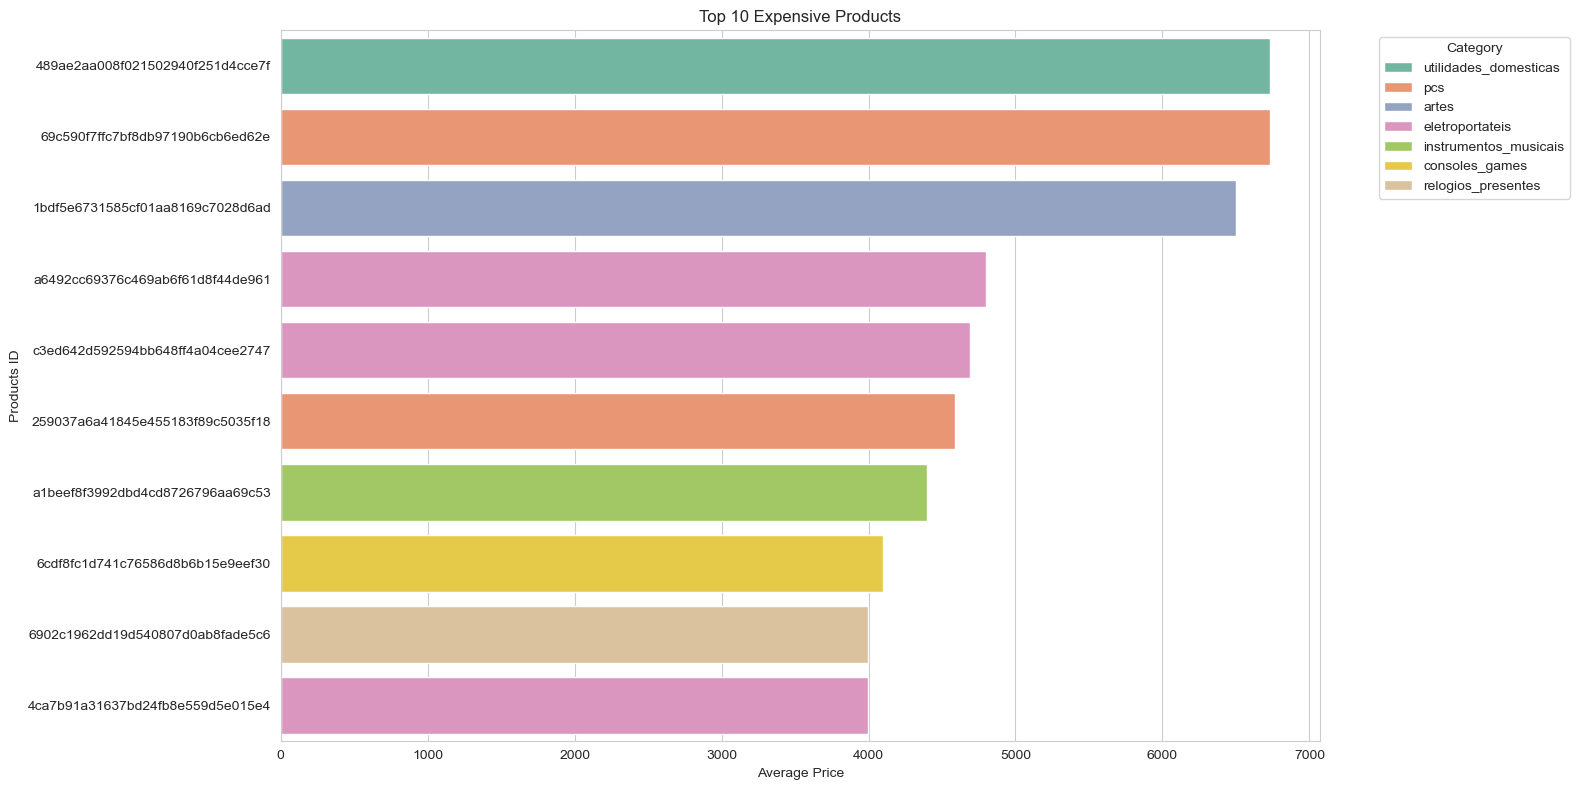

In [331]:
# Top 10 most expensive products by price

top_10_products = (products_data.groupby(['product_id', 'product_category_name'])['price'].mean().reset_index(name='avg_price'))
top_10_products.sort_values(by='avg_price', ascending = False, ignore_index = True, inplace = True)
top_10_products = top_10_products.iloc[:10, :]
display(top_10_products)

plt.figure(figsize=(16,8))
sns.barplot(top_10_products,x='avg_price', y= 'product_id', hue = 'product_category_name', palette = 'Set2')

plt.title('Top 10 Expensive Products')
plt.xlabel('Average Price')
plt.ylabel('Products ID')
plt.legend(title='Category', bbox_to_anchor = (1.05,1), loc = 'upper left')

plt.tight_layout()
plt.show()


,customer_id,total_spend_amt,cut_rev_group
0,a790343ca6f3fee08112d678b43aa7c5,9.59,0-1000
1,184e8e8e48937145eb96c721ef1f0747,10.07,0-1000
2,8e4bd65db637116b6b68109e4df21b84,10.89,0-1000
3,046f890135acc703faff4c1fc0c2d73c,11.56,0-1000
4,d2c63ad286e3ca9dd69218008d61ff81,11.62,0-1000
...,...,...,...
96272,3fd6777bbce08a352fddd04e4a7cc8f6,6726.66,6001-7000
96273,f48d464a0baaea338cb25f816991ab1f,6922.21,6001-7000
96274,c6e2731c5b391845f6800c97401a43a9,6929.31,6001-7000
96275,ec5b2ba62e574342386871631fafd3fc,7274.88,7001-8000


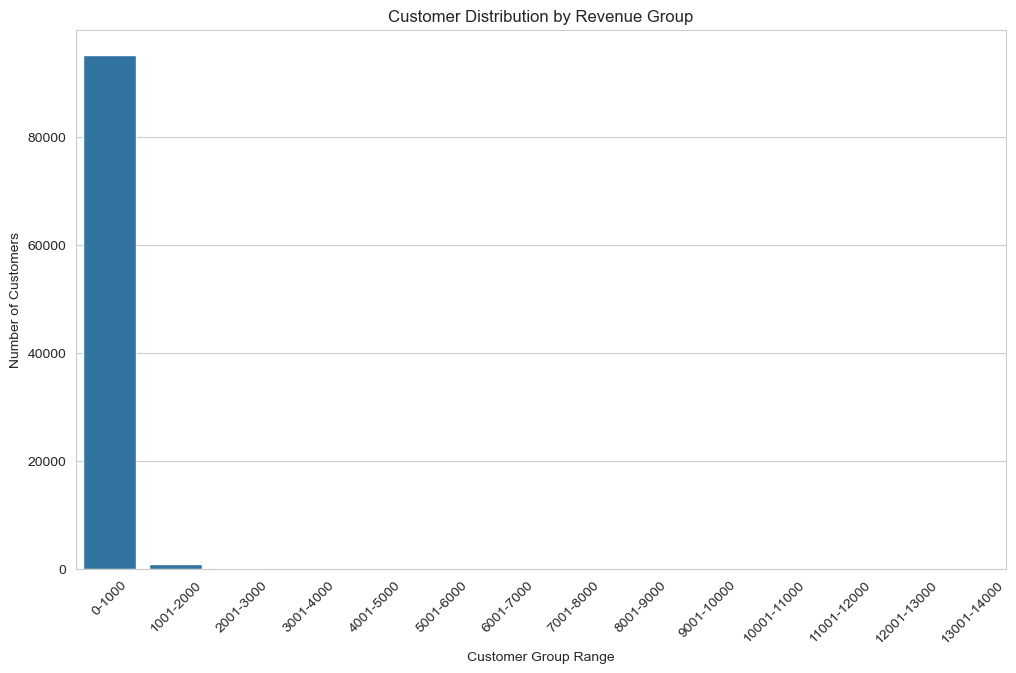

In [332]:
# Divide the customer group based on revenue generated

customer_group = products_data.groupby('customer_id')['gross_revenue'].sum().reset_index()
customer_group.rename(columns={'gross_revenue': 'total_spend_amt'}, inplace=True)
customer_group['cut_rev_group'] = pd.cut(
    customer_group.total_spend_amt, 
    bins = np.arange(0, 15000, 1000),
    labels = ['0-1000', '1001-2000', '2001-3000', '3001-4000', '4001-5000', '5001-6000','6001-7000','7001-8000','8001-9000',
              '9001-10000', '10001-11000', '11001-12000', '12001-13000', '13001-14000'])

customer_group.sort_values(by='total_spend_amt', ascending = True, ignore_index = True, inplace=True)
display(customer_group)

plt.figure(figsize=(12,7))
sns.countplot(x='cut_rev_group', data=customer_group, order=customer_group['cut_rev_group'].cat.categories)
plt.title('Customer Distribution by Revenue Group')
plt.xlabel('Customer Group Range')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.show()


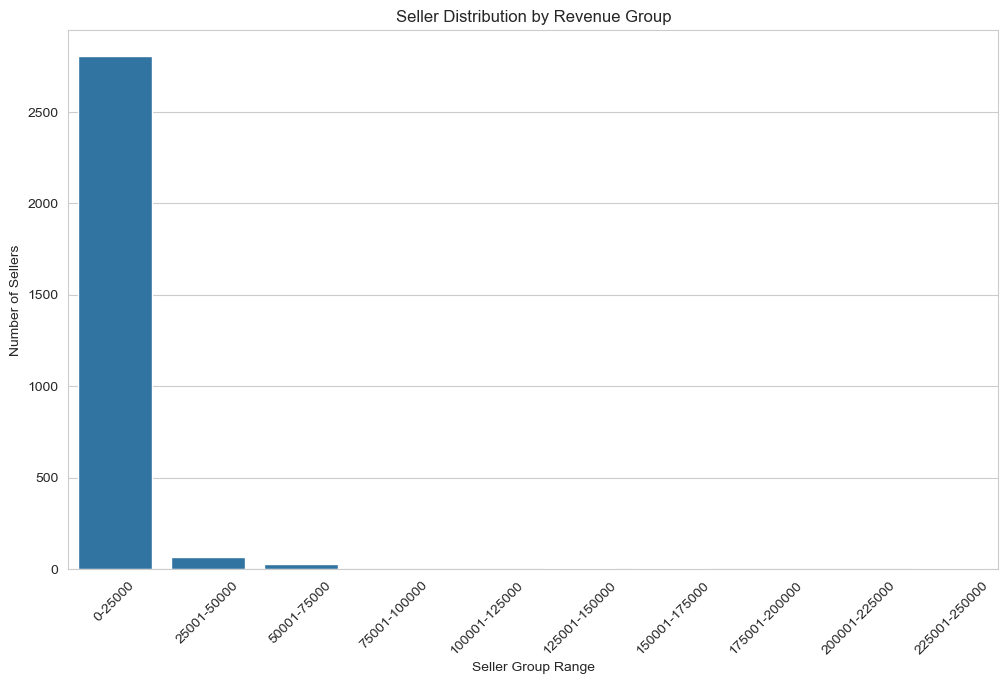

In [333]:
# Divide the customer group based on revenue generated

seller_group = products_data.groupby('seller_id')['gross_revenue'].sum().reset_index()
seller_group.rename(columns={'gross_revenue': 'total_sell_amt'}, inplace=True)
seller_group['seller_rev_group'] = pd.cut(
    seller_group.total_sell_amt, 
    bins = np.arange(0, 250001, 25000),
    labels = ['0-25000', '25001-50000', '50001-75000', '75001-100000',
    '100001-125000', '125001-150000', '150001-175000', '175001-200000', '200001-225000', '225001-250000'])

seller_group.sort_values(by='total_sell_amt', ascending = True, ignore_index = True, inplace=True)
seller_group

plt.figure(figsize=(12,7))
sns.countplot(x='seller_rev_group', data=seller_group, order=seller_group['seller_rev_group'].cat.categories)
plt.title('Seller Distribution by Revenue Group')
plt.xlabel('Seller Group Range')
plt.ylabel('Number of Sellers')
plt.xticks(rotation=45)
plt.show()

In [334]:
# decile analysis of seller

seller_segment = products_data.groupby('seller_id')['price'].sum().reset_index()
seller_segment.rename(columns={'price': 'total_sold_amt'}, inplace=True)
seller_segment['segment'] = pd.qcut(
    seller_segment['total_sold_amt'], q = 10, labels = range(1,11))

seller_segment = seller_segment.sort_values(by=['total_sold_amt', 'segment'], ascending = True, ignore_index = True)
display(seller_segment)

,seller_id,total_sold_amt,segment
0,77128dec4bec4878c37ab7d6169d6f26,6.50,1
1,1fa2d3def6adfa70e58c276bb64fe5bb,6.90,1
2,ad14615bdd492b01b0d97922e87cb87f,8.25,1
3,4965a7002cca77301c82d3f91b82e1a9,8.49,1
4,0f94588695d71662beec8d883ffacf09,9.00,1
...,...,...,...
2915,7c67e1448b00f6e969d365cea6b010ab,187473.91,10
2916,fa1c13f2614d7b5c4749cbc52fecda94,192553.33,10
2917,4a3ca9315b744ce9f8e9374361493884,200383.02,10
2918,53243585a1d6dc2643021fd1853d8905,220199.44,10


#### Cross selling analysis
* Need to find top 10 combination of products are selling together in each transection

#### Market Busket analysis

In [335]:
# Group orders with only multiple item
multi_item_orders = products_data.groupby('order_id').filter(lambda x: len(x)>1)

# Group Product id by order id and convert them to list to get order with multiple items
orders_products_mltp = multi_item_orders.groupby('order_id')['product_id'].apply(list)

# Generate all possible unique pairs and triplates from order_products
from itertools import combinations # possible combination of input iterable like list or set, without repetation
from collections import Counter # To show how many times each pair appear accross all orders

# store combination
combo_counuter_2 = Counter()
combo_counuter_3 = Counter()

for product in orders_products_mltp:
    unique_products = list(set(product))

    # Pairs (pair of 2 products combination)
    for combo in combinations(sorted(unique_products),2):
        combo_counuter_2[combo] +=1
    # Triples (pair of 2 products combination)
    for combo in combinations(sorted(unique_products),3):
        combo_counuter_3[combo] +=1

In [336]:
top_10_pairs = combo_counuter_2.most_common(10)

top_10_triples = combo_counuter_3.most_common(10)

print('Top 10 combined products which are sold in pair set: \n')
display(top_10_pairs)

print('Top 10 combined products which are sold in triples set: \n')
display(top_10_triples)

Top 10 combined products which are sold in pair set: 



[(('36f60d45225e60c7da4558b070ce4b60', 'e53e557d5a159f5aa2c5e995dfdf244b'),
  34),
 (('35afc973633aaeb6b877ff57b2793310', '99a4788cb24856965c36a24e339b6058'),
  29),
 (('4fcb3d9a5f4871e8362dfedbdb02b064', 'f4f67ccaece962d013a4e1d7dc3a61f7'),
  17),
 (('36f60d45225e60c7da4558b070ce4b60', '3f14d740544f37ece8a9e7bc8349797e'),
  12),
 (('389d119b48cf3043d311335e499d9c6b', '422879e10f46682990de24d770e7f83d'),
  11),
 (('389d119b48cf3043d311335e499d9c6b', '53759a2ecddad2bb87a079a1f1519f73'), 9),
 (('368c6c730842d78016ad823897a372db', '53759a2ecddad2bb87a079a1f1519f73'), 8),
 (('18486698933fbb64af6c0a255f7dd64c', 'dbb67791e405873b259e4656bf971246'), 7),
 (('422879e10f46682990de24d770e7f83d', '53759a2ecddad2bb87a079a1f1519f73'), 7),
 (('060cb19345d90064d1015407193c233d', '98d61056e0568ba048e5d78038790e77'), 6)]

Top 10 combined products which are sold in triples set: 



[(('55bfa0307d7a46bed72c492259921231',
   'b9900407a55cb2b306ae612415c3340e',
   'e2cac69b319c0f8a21dbf04b925121bf'),
  3),
 (('1dc7685f4fdb9622d84ae2ec658d5bbf',
   'b7d2c90f9161dc69fa75d22572003bc4',
   'e256d05115f9eb3766f3ab752132a4e2'),
  2),
 (('4025ee582ef6b8c478af3b44cf89054b',
   'c211ff3068fcd2f8898192976d8b3a32',
   'f4d705aa95ccca448e5b0deb6e5290ba'),
  2),
 (('389d119b48cf3043d311335e499d9c6b',
   '422879e10f46682990de24d770e7f83d',
   '53759a2ecddad2bb87a079a1f1519f73'),
  2),
 (('368c6c730842d78016ad823897a372db',
   '389d119b48cf3043d311335e499d9c6b',
   '53759a2ecddad2bb87a079a1f1519f73'),
  2),
 (('1dc7685f4fdb9622d84ae2ec658d5bbf',
   'a46875fb5b8d19ac3cff18deb9bae57e',
   'e256d05115f9eb3766f3ab752132a4e2'),
  2),
 (('23ab7bb9eac81e85ec43ed71064cf7ce',
   '946344697156947d846d27fe0d503033',
   'ad0a798e7941f3a5a2fb8139cb62ad78'),
  2),
 (('946344697156947d846d27fe0d503033',
   'ad0a798e7941f3a5a2fb8139cb62ad78',
   'b0c89945c034268074f5f80b362bda34'),
  2),
 (('35af

In [337]:
# Line 1: Filter the dataframe using the duplicated mask, then sort
cross_selling = products_data[products_data.duplicated(['order_purchase_timestamp', 'customer_id'], 
                                                                keep=False)].sort_values(by='order_purchase_timestamp')

# Line 2: Select specific columns
cross_selling = cross_selling.loc[:, ['customer_id', 'order_purchase_timestamp', 'product_id']]

# Line 3: Remove duplicate product entries (if a user bought the same item twice in one order)
cross_selling.drop_duplicates(subset='product_id', inplace=True)

# Line 4: Final filter and reset index
cross_selling = cross_selling[cross_selling.duplicated(['order_purchase_timestamp', 'customer_id'], 
                                                        keep=False)].sort_values(by='order_purchase_timestamp').reset_index(drop=True)

print('Products with same customer id and order purchase timestamp are cross selling')
cross_selling

Products with same customer id and order purchase timestamp are cross selling


,customer_id,order_purchase_timestamp,product_id
0,08c5351a6aca1c1589a38f244edeee9d,2016-09-04 21:15:19,f293394c72c9b5fafd7023301fc21fc2
1,08c5351a6aca1c1589a38f244edeee9d,2016-09-04 21:15:19,c1488892604e4ba5cff5b4eb4d595400
2,a0f95ab56c6d3a5ba0036b7fdfeda07f,2016-10-04 15:02:53,79938780eb7ffb7289f59a9a283bc06b
3,a0f95ab56c6d3a5ba0036b7fdfeda07f,2016-10-04 15:02:53,8f1e43e0e3374ed8c84df748034d6179
4,00474d2582fd72663036795b7ab8cfc1,2016-10-04 22:33:44,dc82d7e8f99966cb4c641f7ea5590eaf
...,...,...,...
3436,72a366446dd3abfc90c598896714d85c,2018-08-26 11:02:58,e869c12a2f4763dbfc1a8398d20a1213
3437,e5a8aaccb766e00177b0a587979cc814,2018-08-26 11:44:34,3af5874bd2429ed183a5445d1432fcde
3438,e5a8aaccb766e00177b0a587979cc814,2018-08-26 11:44:34,df4bcf4a328103951507064660c445e9
3439,c24bbeb8111fea27eab791a37e665210,2018-08-27 12:39:11,b6b220a6c539cb65be34eed6fea8fe63


In [339]:
# Payment Behavier

# a. How customers are paying?
payments_types = payments.payment_type.drop_duplicates().reset_index().drop(columns='index')
print('Customers are paying by credit cards, UPIs, Vouchars, and Debit cards.')
payments_types

Customers are paying by credit cards, UPIs, Vouchars, and Debit cards.


,payment_type
0,credit_card
1,boleto
2,voucher
3,debit_card
4,unknown


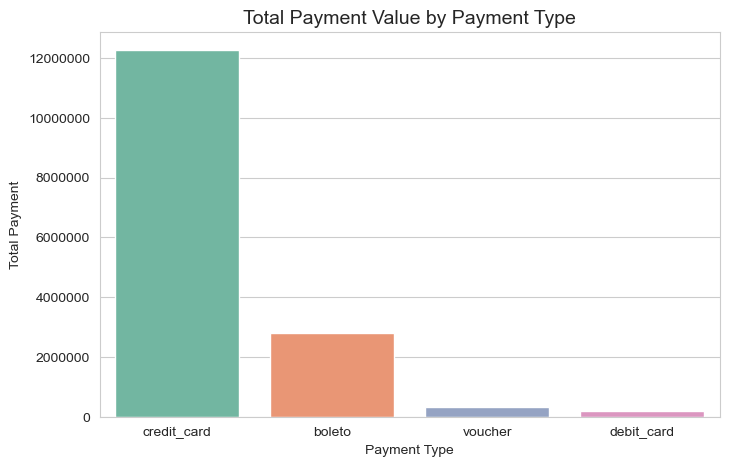

,payment_type,total_trans,total_cust,total_payment
0,credit_card,75500,75215,12254265.98
1,boleto,19395,19395,2793561.05
2,voucher,5581,3727,347291.86
3,debit_card,1508,1507,211081.92


In [345]:
import warnings
warnings.filterwarnings('ignore')

# Merge payments with orders to link customers
payments_by_cust = pd.merge(
    payments,
    order[['order_id', 'customer_id']],
    on='order_id',
    how='inner'
)

# Group by payment type and calculate metrics
pmt = payments_by_cust.groupby('payment_type').agg(
    total_trans=('order_id', 'count'),         # total transactions
    total_cust=('customer_id', 'nunique'),     # unique customers
    total_payment=('payment_value', 'sum')      # <--- CHANGED FROM 'amount' TO 'payment_value'
)

# Sort by total payment value
pmt = pmt.sort_values(by=['total_payment'], ascending=False).reset_index()

# Visualize result
plt.figure(figsize=(8,5))
sns.barplot(data=pmt, x='payment_type', y='total_payment', palette="Set2")
plt.title("Total Payment Value by Payment Type", fontsize=14)
plt.xlabel("Payment Type")
plt.ylabel("Total Payment")
plt.ticklabel_format(style='plain', axis='y')
plt.show()

display(pmt)

##### Most customers pay by credit card, and it brings the highest revenue.
##### UPI is widely used but mainly for small payments.
##### Debit cards are rarely used, while vouchers are used for discounts and repeat buys.


### Customer Satisfaction Analysis

In [349]:
# Prepare data for customer satisfaction analysis

# 1. Merge review data with orders
review_orders = pd.merge(
    order[['order_id', 'customer_id', 'order_Month']],
    order_review[['review_id', 'order_id', 'review_score']],
    on='order_id',
    how='inner'
)

# 2. Merge with order items to bring product and seller info
review_items = pd.merge(
    review_orders,
    order_items[['order_id', 'product_id', 'seller_id', 'price']],
    on='order_id',
    how='inner'
)

# 3. Merge with products to get category (left join to keep all items)
review_items = pd.merge(
    review_items,
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

# 4. Merge with customers to add location info
review_items = pd.merge(
    review_items,
    customer[['customer_id', 'customer_zip_code_prefix', 'customer_state']],
    on='customer_id',
    how='left'
)

# 5. Merge with geolocation data for city/state mapping
review_items = pd.merge(
    review_items,
    geolocation[['geolocation_zip_code_prefix', 'geolocation_city', 'geolocation_state']],
    left_on=['customer_zip_code_prefix', 'customer_state'],
    right_on=['geolocation_zip_code_prefix', 'geolocation_state'],
    how='left'
)

# 6. Handle missing product categories safely
review_items['product_category_name'] = review_items['product_category_name'].fillna('unknown')

# Final dataset ready for customer satisfaction analysis
review_items

,order_id,customer_id,order_Month,review_id,review_score,product_id,seller_id,price,product_category_name,customer_zip_code_prefix,customer_state,geolocation_zip_code_prefix,geolocation_city,geolocation_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10,a54f0611adc9ed256b57ede6b6eb5114,4,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,utilidades_domesticas,3149,SP,3149.0,sao paulo,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10,a54f0611adc9ed256b57ede6b6eb5114,4,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,utilidades_domesticas,3149,SP,3149.0,sao paulo,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10,a54f0611adc9ed256b57ede6b6eb5114,4,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,utilidades_domesticas,3149,SP,3149.0,sao paulo,SP
3,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10,a54f0611adc9ed256b57ede6b6eb5114,4,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,utilidades_domesticas,3149,SP,3149.0,sao paulo,SP
4,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10,a54f0611adc9ed256b57ede6b6eb5114,4,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,utilidades_domesticas,3149,SP,3149.0,sao paulo,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16973218,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,2018-03,dc9c59b4688062c25758c2be4cafc523,5,006619bbed68b000c8ba3f8725d5409e,ececbfcff9804a2d6b40f589df8eef2b,68.50,beleza_saude,83750,PR,83750.0,lapa,PR
16973219,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,2018-03,dc9c59b4688062c25758c2be4cafc523,5,006619bbed68b000c8ba3f8725d5409e,ececbfcff9804a2d6b40f589df8eef2b,68.50,beleza_saude,83750,PR,83750.0,lapa,PR
16973220,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,2018-03,dc9c59b4688062c25758c2be4cafc523,5,006619bbed68b000c8ba3f8725d5409e,ececbfcff9804a2d6b40f589df8eef2b,68.50,beleza_saude,83750,PR,83750.0,lapa,PR
16973221,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,2018-03,dc9c59b4688062c25758c2be4cafc523,5,006619bbed68b000c8ba3f8725d5409e,ececbfcff9804a2d6b40f589df8eef2b,68.50,beleza_saude,83750,PR,83750.0,lapa,PR


In [352]:
# a. Which categories (top 10) are maximum rated & minimum rated?

# Step 1: Rating by category
cat_rating = review_items.groupby('product_category_name')['review_score'].agg(
    avg_rating='mean',
    rating_count='count'
).reset_index()

# Step 2: Global mean rating
C = cat_rating['avg_rating'].mean()

# Step 3: Choose m (minimum rating count required)
# For balanced results, use 80th percentile of rating_count
m = int(cat_rating['rating_count'].quantile(0.80))

# Step 4: Bayesian average (Weighted Rating formula)
cat_rating['weighted_rating'] = (
    (cat_rating['rating_count'] / (cat_rating['rating_count'] + m)) * cat_rating['avg_rating']
    + (m / (cat_rating['rating_count'] + m)) * C
)

# Step 5: Top & Bottom categories
top_rated_cat = cat_rating.sort_values(by='weighted_rating', ascending=False, ignore_index=True).head(10)
min_rated_cat = cat_rating.sort_values(by='weighted_rating', ascending=True, ignore_index=True).head(10)

print("Top 10 categories with highest ratings (Weighted Rating)\n")
display(top_rated_cat)

print("\nTop 10 categories with lowest ratings (Weighted Rating)\n")
display(min_rated_cat)

# Note : here review count also matters so I used this but it gives fluctuated review_counts with respect to their rating.
#        count has higher precedence whereas 4.3451 rating with 1075 has lower precedence so use bayesian average or weighted rating.

Top 10 categories with highest ratings (Weighted Rating)



,product_category_name,avg_rating,rating_count,weighted_rating
0,malas_acessorios,4.390538,171479,4.185229
1,brinquedos,4.224866,636552,4.175578
2,papelaria,4.253129,378614,4.172984
3,beleza_saude,4.194360,1383250,4.172549
4,perfumaria,4.224211,509365,4.168294
5,livros_interesse_geral,4.467806,79954,4.158788
6,eletroportateis,4.355897,112409,4.153782
7,pet_shop,4.200231,324020,4.143147
8,cool_stuff,4.167019,542787,4.137253
9,livros_tecnicos,4.458397,42112,4.131259



Top 10 categories with lowest ratings (Weighted Rating)



,product_category_name,avg_rating,rating_count,weighted_rating
0,moveis_escritorio,3.529673,264161,3.870090
1,cama_mesa_banho,3.868265,1749109,3.910503
2,moveis_decoracao,3.917309,1338943,3.958308
3,informatica_acessorios,3.942738,1202309,3.980927
4,telefonia,3.933470,597231,3.998600
5,moveis_sala,3.812732,83410,4.047291
6,unknown,3.968400,233006,4.049167
7,relogios_presentes,4.041888,851198,4.059280
8,casa_conforto,3.866951,67133,4.063357
9,telefonia_fixa,3.708135,34653,4.065385


Top 10 Products with Highest Ratings



,product_id,avg_rating,rating_count
0,16ce899c7af0c99f46948734a0d00f0f,5.0,6205
1,0c9439abe84dc40a64fc164365c4d064,5.0,5878
2,002af88741ba70c7b5cf4e4a0ad7ef85,5.0,4278
3,c2c989ac5100e59a6c3d12b2c31a2c72,5.0,4176
4,26c6145c9687019a428467c8852ae36b,5.0,3530
5,64143bc1c8b26719d98b7b0ab8027ad9,5.0,3396
6,36df104745cb6dd332bd1eff627af709,5.0,3240
7,03e1c946c0ddfc58724ff262aef08dff,5.0,3202
8,ec3f8e78677c7e0395b155bc67417158,5.0,3034
9,c974196c0f8fa41b6475a72f67b8df99,5.0,2940



Top 10 Products with Lowest Ratings



,product_id,avg_rating,rating_count
0,0ecaf0629e5e227413504f3892bd76ba,1.0,2521
1,62995b7e571f5760017991632bbfd311,1.0,2436
2,ac1ad58efc1ebf66bfadc09f29bdedc0,1.0,2436
3,e8a2ee67401eb29a9eba28e2eab61a8b,1.0,2292
4,c183fd5d2abf05873fa6e1014ed9e06c,1.0,2184
5,97fd40ea17a0e785880ce09373b2900a,1.0,2061
6,fb29f48bfea41db52e349454f433340e,1.0,2005
7,03d10117bf5dbd1e4f194566be73de5a,1.0,1923
8,f201c94e7d8aa11b6ab049d69730309d,1.0,1864
9,f83fd2b539bc73678c65be8d418be8c1,1.0,1854


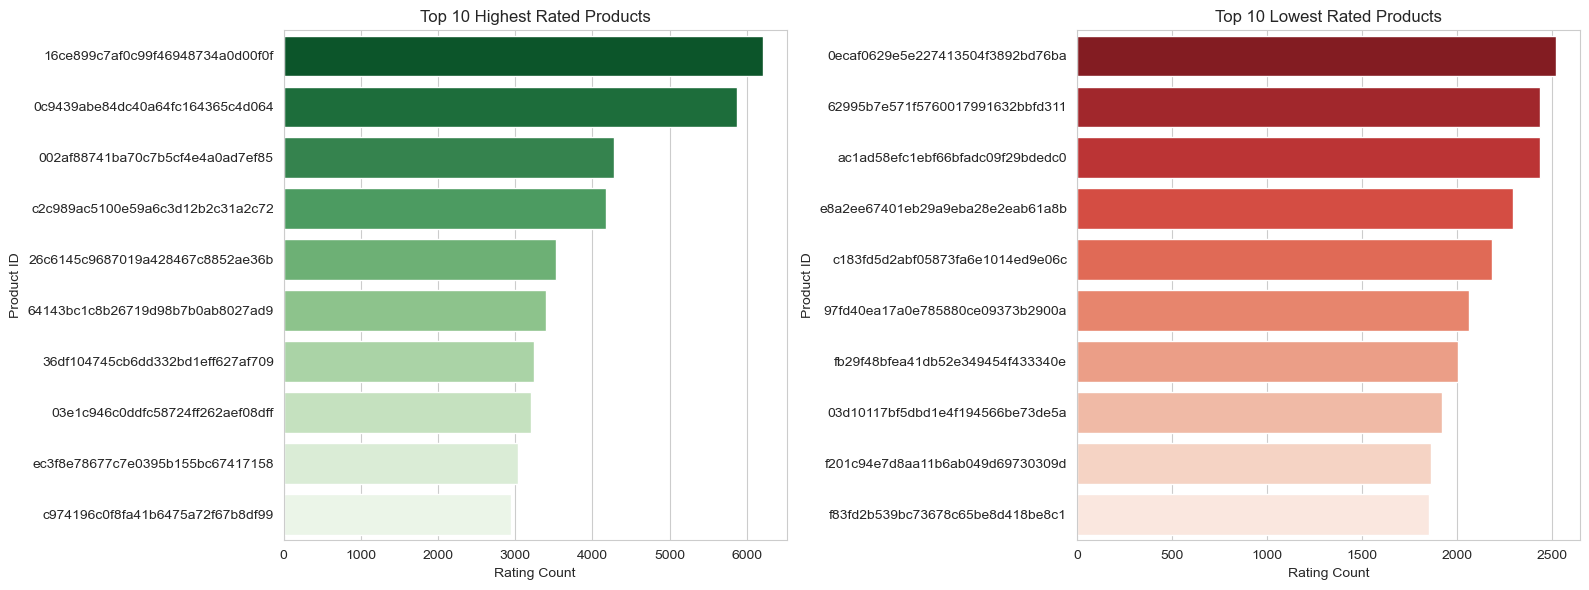

In [353]:
# b. Which products (top 10) are maximum rated & minimum rated?

# Step 1: Rating by product
product_rating = review_items.groupby('product_id')['review_score'].agg(
    avg_rating='mean',
    rating_count='count'
).reset_index()

# Step 2: Sort products by average rating and review count
top10_max_products = product_rating.sort_values(
    by=['avg_rating', 'rating_count'],
    ascending=[False, False],
    ignore_index=True
).head(10)

top10_min_products = product_rating.sort_values(
    by=['avg_rating', 'rating_count'],
    ascending=[True, False],
    ignore_index=True
).head(10)

# Step 3: Display results
print("Top 10 Products with Highest Ratings\n")
display(top10_max_products)

print("\nTop 10 Products with Lowest Ratings\n")
display(top10_min_products)

# Step 4: Visualize results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=top10_max_products,
    x='rating_count',
    y='product_id',
    palette='Greens_r',
    ax=axes[0]
)
axes[0].set_title("Top 10 Highest Rated Products")
axes[0].set_xlabel("Rating Count")
axes[0].set_ylabel("Product ID")

sns.barplot(
    data=top10_min_products,
    x='rating_count',
    y='product_id',
    palette='Reds_r',
    ax=axes[1]
)
axes[1].set_title("Top 10 Lowest Rated Products")
axes[1].set_xlabel("Rating Count")
axes[1].set_ylabel("Product ID")

plt.tight_layout()
plt.show()

In [354]:
# c. Average rating by location

# Step 1: Group by state and city
avg_location_rating = review_items.groupby(
    ['customer_state', 'geolocation_city']
)['review_score'].agg(['mean', 'count']).reset_index()

# Step 2: Rename columns for clarity
avg_location_rating.rename(
    columns={'mean': 'avg_rating', 'count': 'rating_count'},
    inplace=True
)

# Step 3: Sort by state and rating count
avg_location_rating = avg_location_rating.sort_values(
    by=['customer_state', 'rating_count'],
    ascending=[True, False]
)

# Step 4: Display results
print("Average Rating by Location:\n")
display(avg_location_rating)

# Example: filter ratings for a specific state
# avg_location_rating.loc[avg_location_rating['customer_state'] == 'SP']

Average Rating by Location:



,customer_state,geolocation_city,avg_rating,rating_count
8,AC,rio branco,4.057739,7811
2,AC,cruzeiro do sul,4.666667,321
9,AC,senador guiomard,5.000000,45
10,AC,xapuri,5.000000,30
0,AC,brasileia,5.000000,24
...,...,...,...,...
6007,TO,silvanópolis,5.000000,2
5948,TO,araguaçu,4.000000,1
5978,TO,fátima,5.000000,1
6003,TO,pugmil,3.000000,1



Top 10 Highest-Rated Sellers



,seller_id,avg_rating,rating_count
0,48efc9d94a9834137efd9ea76b065a38,5.0,8139
1,c394e193cda3b4225ff2094d32184849,5.0,5878
2,ab27bbbad5239bc31a34709275a70db4,5.0,2677
3,661ad5fcc28cdfb8bcadb12bb2272475,5.0,2447
4,71dc18fd8cbf5fd77f45dd8b427abb34,5.0,2319
5,7994b065a7ffb14e71c6312cf87b9de2,5.0,2129
6,2addf05f476d0637864454e93ba673d5,5.0,2123
7,2bd05d410a8fd26dc4184a15f4f2f588,5.0,2111
8,404e1ba01358af4cd63f679b2c4d1fa1,5.0,2088
9,4049512728d969bec69f84088b012416,5.0,1996



Top 10 Lowest-Rated Sellers



,seller_id,avg_rating,rating_count
0,8d92f3ea807b89465643c219455e7369,1.0,1439
1,391bbd13b6452244774beff1824006ed,1.0,709
2,4342d4b2ba6b161468c63a7e7cfce593,1.0,671
3,1444c08e64d55fb3c25f0f09c07ffcf2,1.0,602
4,244b04680fdbded0acf5aebd9c92b44a,1.0,602
5,4e42581f08e8cfc7c090f930bac4552a,1.0,592
6,791cfcfe22fe4a771ece27f90017da92,1.0,566
7,749e7cdabbaf72f16677859e27874ba5,1.0,506
8,8629a7efec1aab257e58cda559f03ba7,1.0,506
9,553a440137d6e0cf776aee0bb83ac9f5,1.0,501


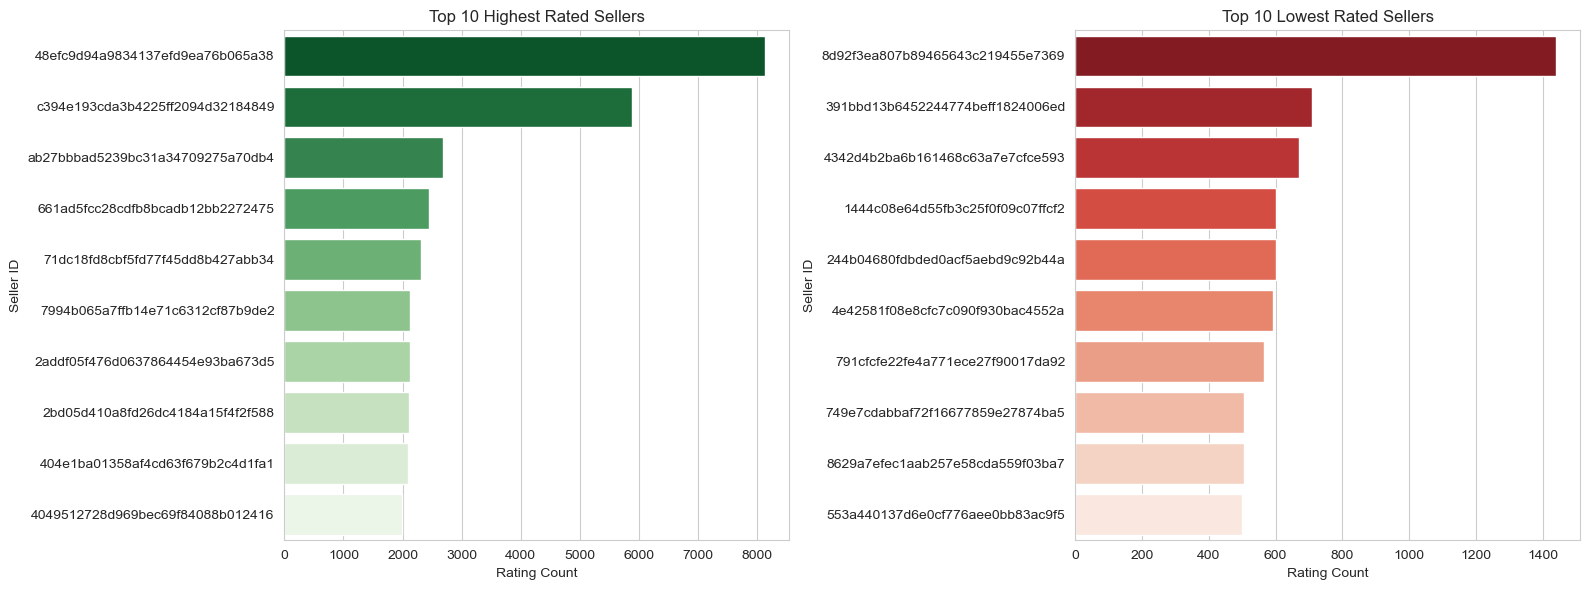

In [355]:
# c. Average rating by seller

# Step 1: Group by seller
avg_seller_rating = review_items.groupby('seller_id')['review_score'].agg(['mean', 'count']).reset_index()

# Step 2: Rename columns for clarity
avg_seller_rating.rename(columns={'mean': 'avg_rating', 'count': 'rating_count'}, inplace=True)

# Step 3: Sort sellers by average rating and review count
top_rated_sellers = avg_seller_rating.sort_values(
    by=['avg_rating', 'rating_count'],
    ascending=[False, False],
    ignore_index=True
)

min_rated_sellers = avg_seller_rating.sort_values(
    by=['avg_rating', 'rating_count'],
    ascending=[True, False],
    ignore_index=True
)

# Step 4: Display results
print("\nTop 10 Highest-Rated Sellers\n")
display(top_rated_sellers.head(10))

print("\nTop 10 Lowest-Rated Sellers\n")
display(min_rated_sellers.head(10))

# Step 5: Visualize results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=top_rated_sellers.head(10),
    y='seller_id',
    x='rating_count',
    palette='Greens_r',
    ax=axes[0]
)
axes[0].set_title("Top 10 Highest Rated Sellers")
axes[0].set_xlabel("Rating Count")
axes[0].set_ylabel("Seller ID")

sns.barplot(
    data=min_rated_sellers.head(10),
    y='seller_id',
    x='rating_count',
    palette='Reds_r',
    ax=axes[1]
)
axes[1].set_title("Top 10 Lowest Rated Sellers")
axes[1].set_xlabel("Rating Count")
axes[1].set_ylabel("Seller ID")

plt.tight_layout()
plt.show()

In [356]:
# c. Average rating by Product

avg_product_rating = review_items.groupby('product_id')['review_score'].agg(['mean', 'count']).reset_index()

# Rename columns for clarity
avg_product_rating.rename(columns={'mean': 'avg_rating', 'count': 'rating_count'}, inplace=True)

# Sort by average rating and rating count
avg_product_rating = avg_product_rating.sort_values(
    by=['avg_rating', 'rating_count'],
    ascending=[False, False],
    ignore_index=True
)

# Display result
print("Average Rating by Product:\n")
display(avg_product_rating)


Average Rating by Product:



,product_id,avg_rating,rating_count
0,16ce899c7af0c99f46948734a0d00f0f,5.0,6205
1,0c9439abe84dc40a64fc164365c4d064,5.0,5878
2,002af88741ba70c7b5cf4e4a0ad7ef85,5.0,4278
3,c2c989ac5100e59a6c3d12b2c31a2c72,5.0,4176
4,26c6145c9687019a428467c8852ae36b,5.0,3530
...,...,...,...
32270,774ad2570c29b52d50433d7bb89273e7,1.0,1
32271,89c111575a1b19782a2e660eff07dd8a,1.0,1
32272,9a1497459e5fa13235a83d67111a8e7b,1.0,1
32273,d359ac1975cd09111b28c63352a88e18,1.0,1


In [357]:
# c. Average rating by Category

avg_cat_rating = review_items.groupby('product_category_name')['review_score'].mean().reset_index()

# Sort by review score
avg_cat_rating = avg_cat_rating.sort_values(
    by='review_score',
    ascending=False,
    ignore_index=True
)

# Display result
print("\nAverage Rating by Category:\n")
display(avg_cat_rating)



Average Rating by Category:



,product_category_name,review_score
0,fashion_roupa_infanto_juvenil,5.000000
1,cds_dvds_musicais,4.818117
2,flores,4.765900
3,portateis_casa_forno_e_cafe,4.590231
4,livros_importados,4.581687
...,...,...
69,artigos_de_festas,3.558895
70,moveis_escritorio,3.529673
71,casa_conforto_2,3.515021
72,fraldas_higiene,2.942176


In [358]:
# c. Average rating by Category

# Step 1: Group by category and calculate mean rating
avg_cat_rating = review_items.groupby('product_category_name')['review_score'].mean().reset_index()

# Step 2: Sort categories by average rating
avg_cat_rating = avg_cat_rating.sort_values(
    by='review_score',
    ascending=False,
    ignore_index=True
)

# Step 3: Display results
print("Average Rating by Category:\n")
display(avg_cat_rating)

Average Rating by Category:



,product_category_name,review_score
0,fashion_roupa_infanto_juvenil,5.000000
1,cds_dvds_musicais,4.818117
2,flores,4.765900
3,portateis_casa_forno_e_cafe,4.590231
4,livros_importados,4.581687
...,...,...
69,artigos_de_festas,3.558895
70,moveis_escritorio,3.529673
71,casa_conforto_2,3.515021
72,fraldas_higiene,2.942176


Average Rating by Month:



,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
order_Month,2016-09,2016-10,2016-12,2017-01,2017-02,2017-03,2017-04,2017-05,2017-06,2017-07,...,2017-12,2018-01,2018-02,2018-03,2018-04,2018-05,2018-06,2018-07,2018-08,2018-09
review_score,1.0,3.73999,5.0,4.187031,4.201957,4.154635,4.099435,4.149531,4.176206,4.169554,...,3.911248,3.945658,3.751336,3.661718,4.114138,4.139453,4.196938,4.300749,4.233546,1.0


<Figure size 800x600 with 0 Axes>

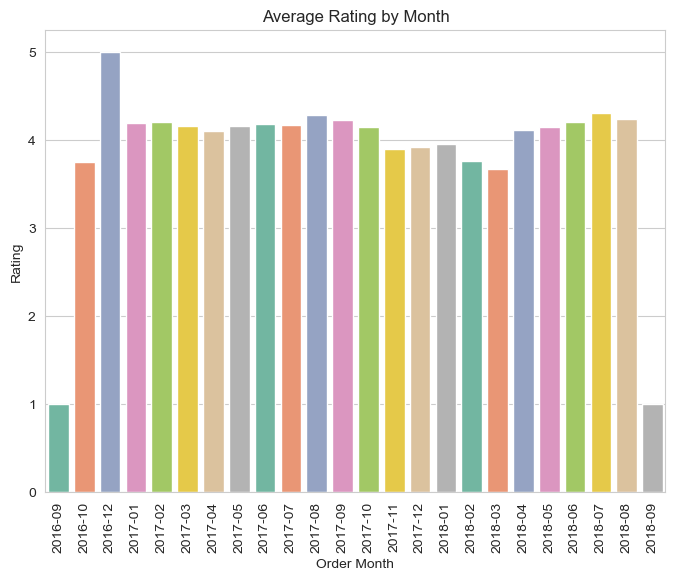

In [362]:
# c. Average rating by month

# Step 1: Group by month and calculate mean rating
average_monthly_rating = review_items.groupby('order_Month')['review_score'].mean().reset_index()

# Step 2: Sort by month
average_monthly_rating = average_monthly_rating.sort_values('order_Month')

# Step 3: Display results (transposed for readability)
print("Average Rating by Month:\n")
display(average_monthly_rating.T)

# Step 4: Visualize results
plt.figure(figsize=(8,6))
sns.barplot(
    data=average_monthly_rating,
    y='review_score',
    x='order_Month',
    palette='Set2'
)
plt.title("Average Rating by Month")
plt.xlabel("Order Month")
plt.ylabel("Rating")
plt.xticks(rotation=90)
plt.show()

In [360]:
review_items.head(5)

,order_id,customer_id,order_Month,review_id,review_score,product_id,seller_id,price,product_category_name,customer_zip_code_prefix,customer_state,geolocation_zip_code_prefix,geolocation_city,geolocation_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10,a54f0611adc9ed256b57ede6b6eb5114,4,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,utilidades_domesticas,3149,SP,3149.0,sao paulo,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10,a54f0611adc9ed256b57ede6b6eb5114,4,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,utilidades_domesticas,3149,SP,3149.0,sao paulo,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10,a54f0611adc9ed256b57ede6b6eb5114,4,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,utilidades_domesticas,3149,SP,3149.0,sao paulo,SP
3,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10,a54f0611adc9ed256b57ede6b6eb5114,4,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,utilidades_domesticas,3149,SP,3149.0,sao paulo,SP
4,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10,a54f0611adc9ed256b57ede6b6eb5114,4,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,29.99,utilidades_domesticas,3149,SP,3149.0,sao paulo,SP


In [364]:
# d. Top 10 Highest-Rated Products by each Month

# Step 1: Group by month, category, and product
prod_monthly_avg_rating = review_items.groupby(
    ['order_Month', 'product_category_name', 'product_id']
)['review_score'].agg(['mean', 'count'])

# Step 2: Rename columns for clarity
prod_monthly_avg_rating = prod_monthly_avg_rating.rename(
    columns={'mean': 'avg_rating', 'count': 'review_count'}
)

# Step 3: Sort by month, average rating, and review count
top_10_highest = prod_monthly_avg_rating.sort_values(
    by=['order_Month', 'avg_rating', 'review_count'],
    ascending=[True, False, False]
).groupby('order_Month').head(10).reset_index()

# Step 4: Display results
print("Top 10 Highest-Rated Products by each Month\n")
display(top_10_highest)

Top 10 Highest-Rated Products by each Month



,order_Month,product_category_name,product_id,avg_rating,review_count
0,2016-09,beleza_saude,5a6b04657a4c5ee34285d1e4619a96b4,1.0,1035
1,2016-09,moveis_decoracao,c1488892604e4ba5cff5b4eb4d595400,1.0,65
2,2016-09,moveis_decoracao,f293394c72c9b5fafd7023301fc21fc2,1.0,65
3,2016-10,moveis_decoracao,bdcec8e22b04a8f4241d87bcfe9ea877,5.0,2382
4,2016-10,climatizacao,cfd43c5e600d45ac029357406b05dd82,5.0,1244
...,...,...,...,...,...
210,2018-08,utilidades_domesticas,8d1e9f9f3d7126c5ccdfb50c10c8e444,5.0,1304
211,2018-08,pet_shop,e3dd5a5b73bfbb610ada4ed74a6612b6,5.0,1292
212,2018-08,beleza_saude,83b23a333b811855258c5ec9431f6d3e,5.0,1243
213,2018-08,cama_mesa_banho,5360ece40f89cf47f68ec7353fb12d49,5.0,1224


In [376]:
# Step 1: Remove duplicate review entries if they exist
# This ensures one order/product/review combo is counted once
review_items_clean = review_items.drop_duplicates(subset=['order_id', 'product_id', 'review_id'])

# Step 2: Re-calculate your monthly averages
prod_monthly_avg_rating = review_items_clean.groupby(['order_Month', 'product_id', 'product_category_name']).agg(
    avg_rating=('review_score', 'mean'),
    review_count=('review_score', 'count')
).reset_index()

# Step 3: Now run your top 10 lowest logic
top_10_lowest = prod_monthly_avg_rating.sort_values(
    by=['order_Month', 'avg_rating', 'review_count'],
    ascending=[True, True, False]
).groupby('order_Month').head(10).reset_index(drop=True)

display(top_10_lowest)

,order_Month,product_id,product_category_name,avg_rating,review_count
0,2016-09,5a6b04657a4c5ee34285d1e4619a96b4,beleza_saude,1.0,1
1,2016-09,c1488892604e4ba5cff5b4eb4d595400,moveis_decoracao,1.0,1
2,2016-09,f293394c72c9b5fafd7023301fc21fc2,moveis_decoracao,1.0,1
3,2016-10,8f1e43e0e3374ed8c84df748034d6179,beleza_saude,1.0,2
4,2016-10,e41a6ac2f57a273eb0d214c7cbab5db9,moveis_escritorio,1.0,2
...,...,...,...,...,...
210,2018-08,0333795efd58e3c33c5850b92721c3e4,moveis_decoracao,1.0,1
211,2018-08,046bb8477448980cb3355e0702e77a0e,beleza_saude,1.0,1
212,2018-08,04fd8d64a2539d188bef33bb288410bb,cama_mesa_banho,1.0,1
213,2018-08,064c975d37d3c646bd94d94c6e16f37e,utilidades_domesticas,1.0,1
